In [2]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

In [61]:
ds_1 = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-04_updated_glimmer/scenario_development/Detached/case_07_cold_start_detached_20_cores', guard_replace = False, use_squash=True).ds
ds_old_1 = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01'  , guard_replace = False, use_squash=True).ds

- Looking for squash file
- Squash file found. squash date 04/24/2025, 11:12:33, dmp file date 04/24/2025, 04:53:31
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/23/2025, 20:04:43, dmp file date 11/26/2024, 06:50:17
Skipping unnormalisation


In [70]:
print(ds_old.data_vars)

Data variables:
    Bxy                      (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_iz                   (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_rec                  (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_sheath               (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed_target_recycle        (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Edd+_cx                  (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ee_sheath                (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    EnergyFlow_d+_ylow       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    EnergyFlow_e_ylow        (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_iz                   (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_rec                  (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    F

# Macro profiles

In [185]:
def single_profile_plot(ds_in, time, x_log_scale=True, title='None', save=False, save_path=None):

    fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=300)
    linewidth = 2
    ds = ds_in.copy().isel(t=time)
    # ds_old = ds_old_1.copy().isel(t=-1)

    ax2 = ax.twinx()

    ax2.plot(ds['y'][::-1][2:-2], ds['Te'][2:-2], color='blue', label='Te', linewidth=linewidth)
    ax2.plot(ds['y'][::-1][2:-2], ds['Td+'][2:-2], color='red', label='Td+', linewidth=linewidth)

    ax.plot(ds['y'][::-1][2:-2], ds['Ne'][2:-2], color='blue', label='Ne', linewidth=linewidth, linestyle='--')
    ax.plot(ds['y'][::-1][2:-2], ds['Nd'][2:-2], color='black', label='Nd', linewidth=linewidth, linestyle='--')

    if x_log_scale:
        ax.set_xscale('log')
    ax.set_yscale('log')

        
    ax.set_xlabel('Distance to target (m)', fontsize=20)
    ax.set_ylabel(r'Ne,Nd (m$^{-3}$)', fontsize=20)
    ax2.set_ylabel('T (eV)', fontsize=20)
    ax.set_ylim(1e18)
    ax2.grid(False)
    fig.legend(ncol = 4, loc = 'upper right')
    fig.suptitle(f"{(ds_in['t'].values[time] - ds_in['t'].values[0]) *1e3 : 6f} ms", fontsize=20, x=0.0, horizontalalignment='left',)



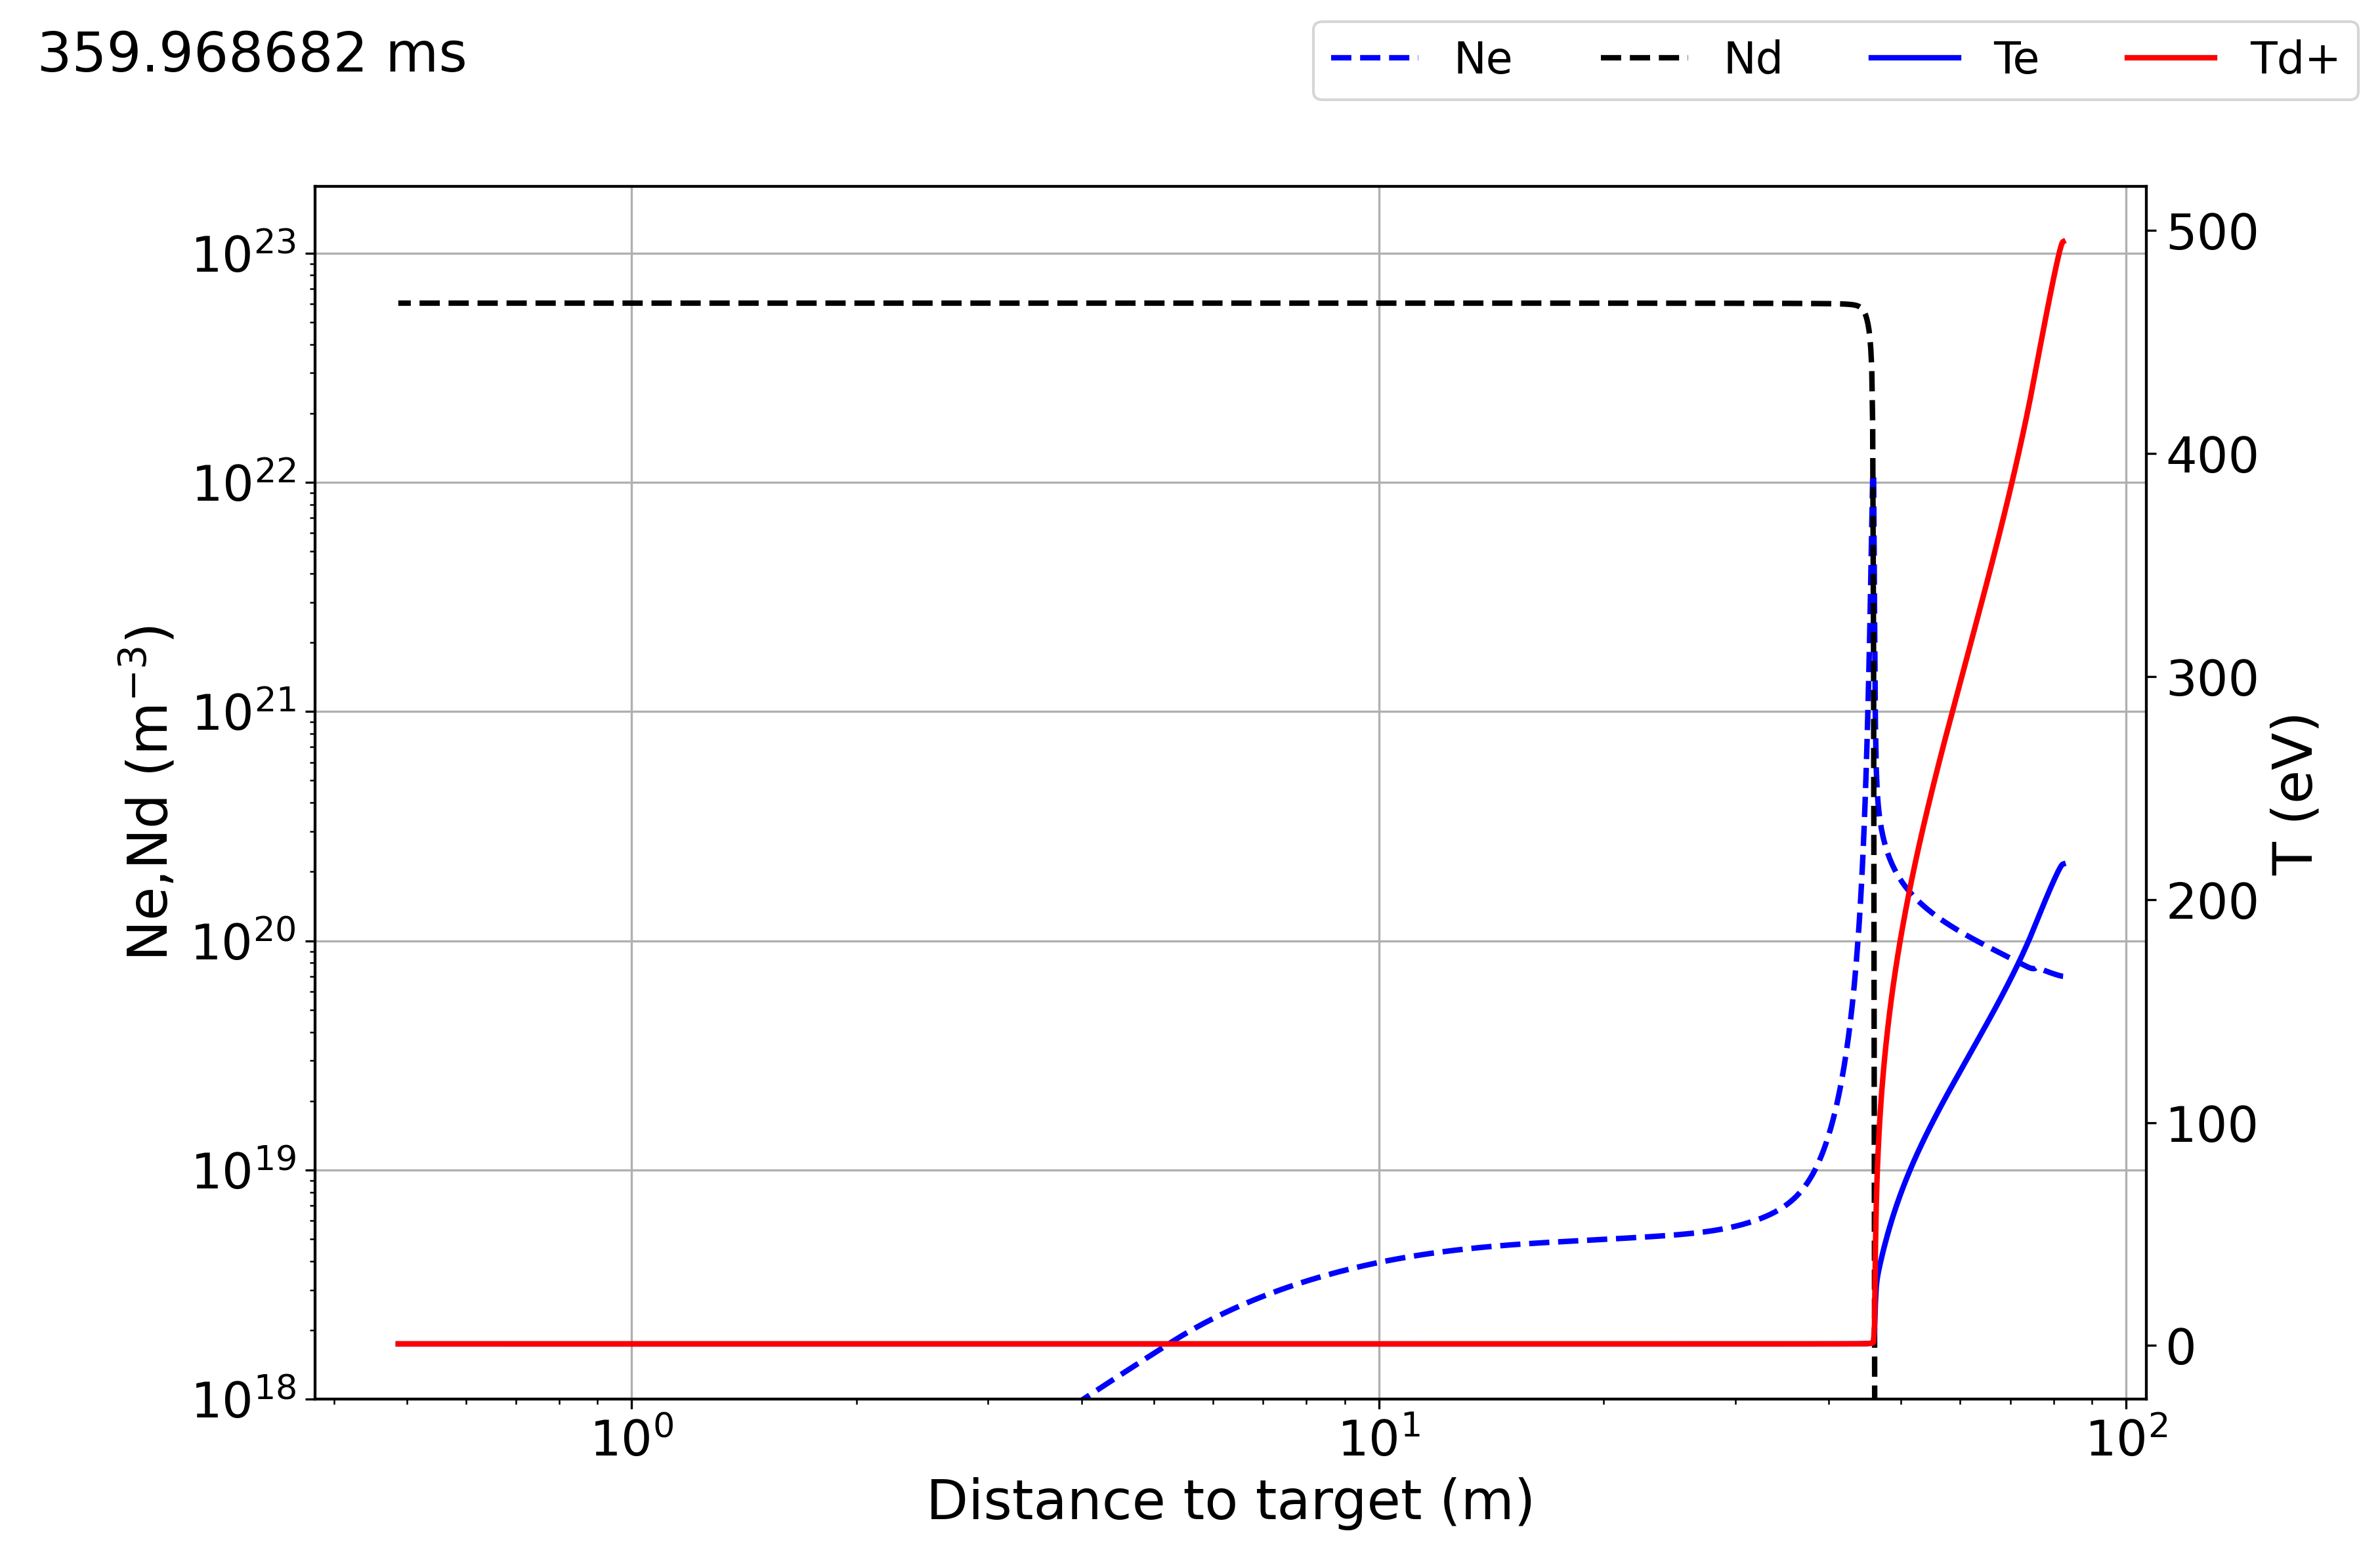

In [186]:
single_profile_plot(ds_1, -1)

index  75


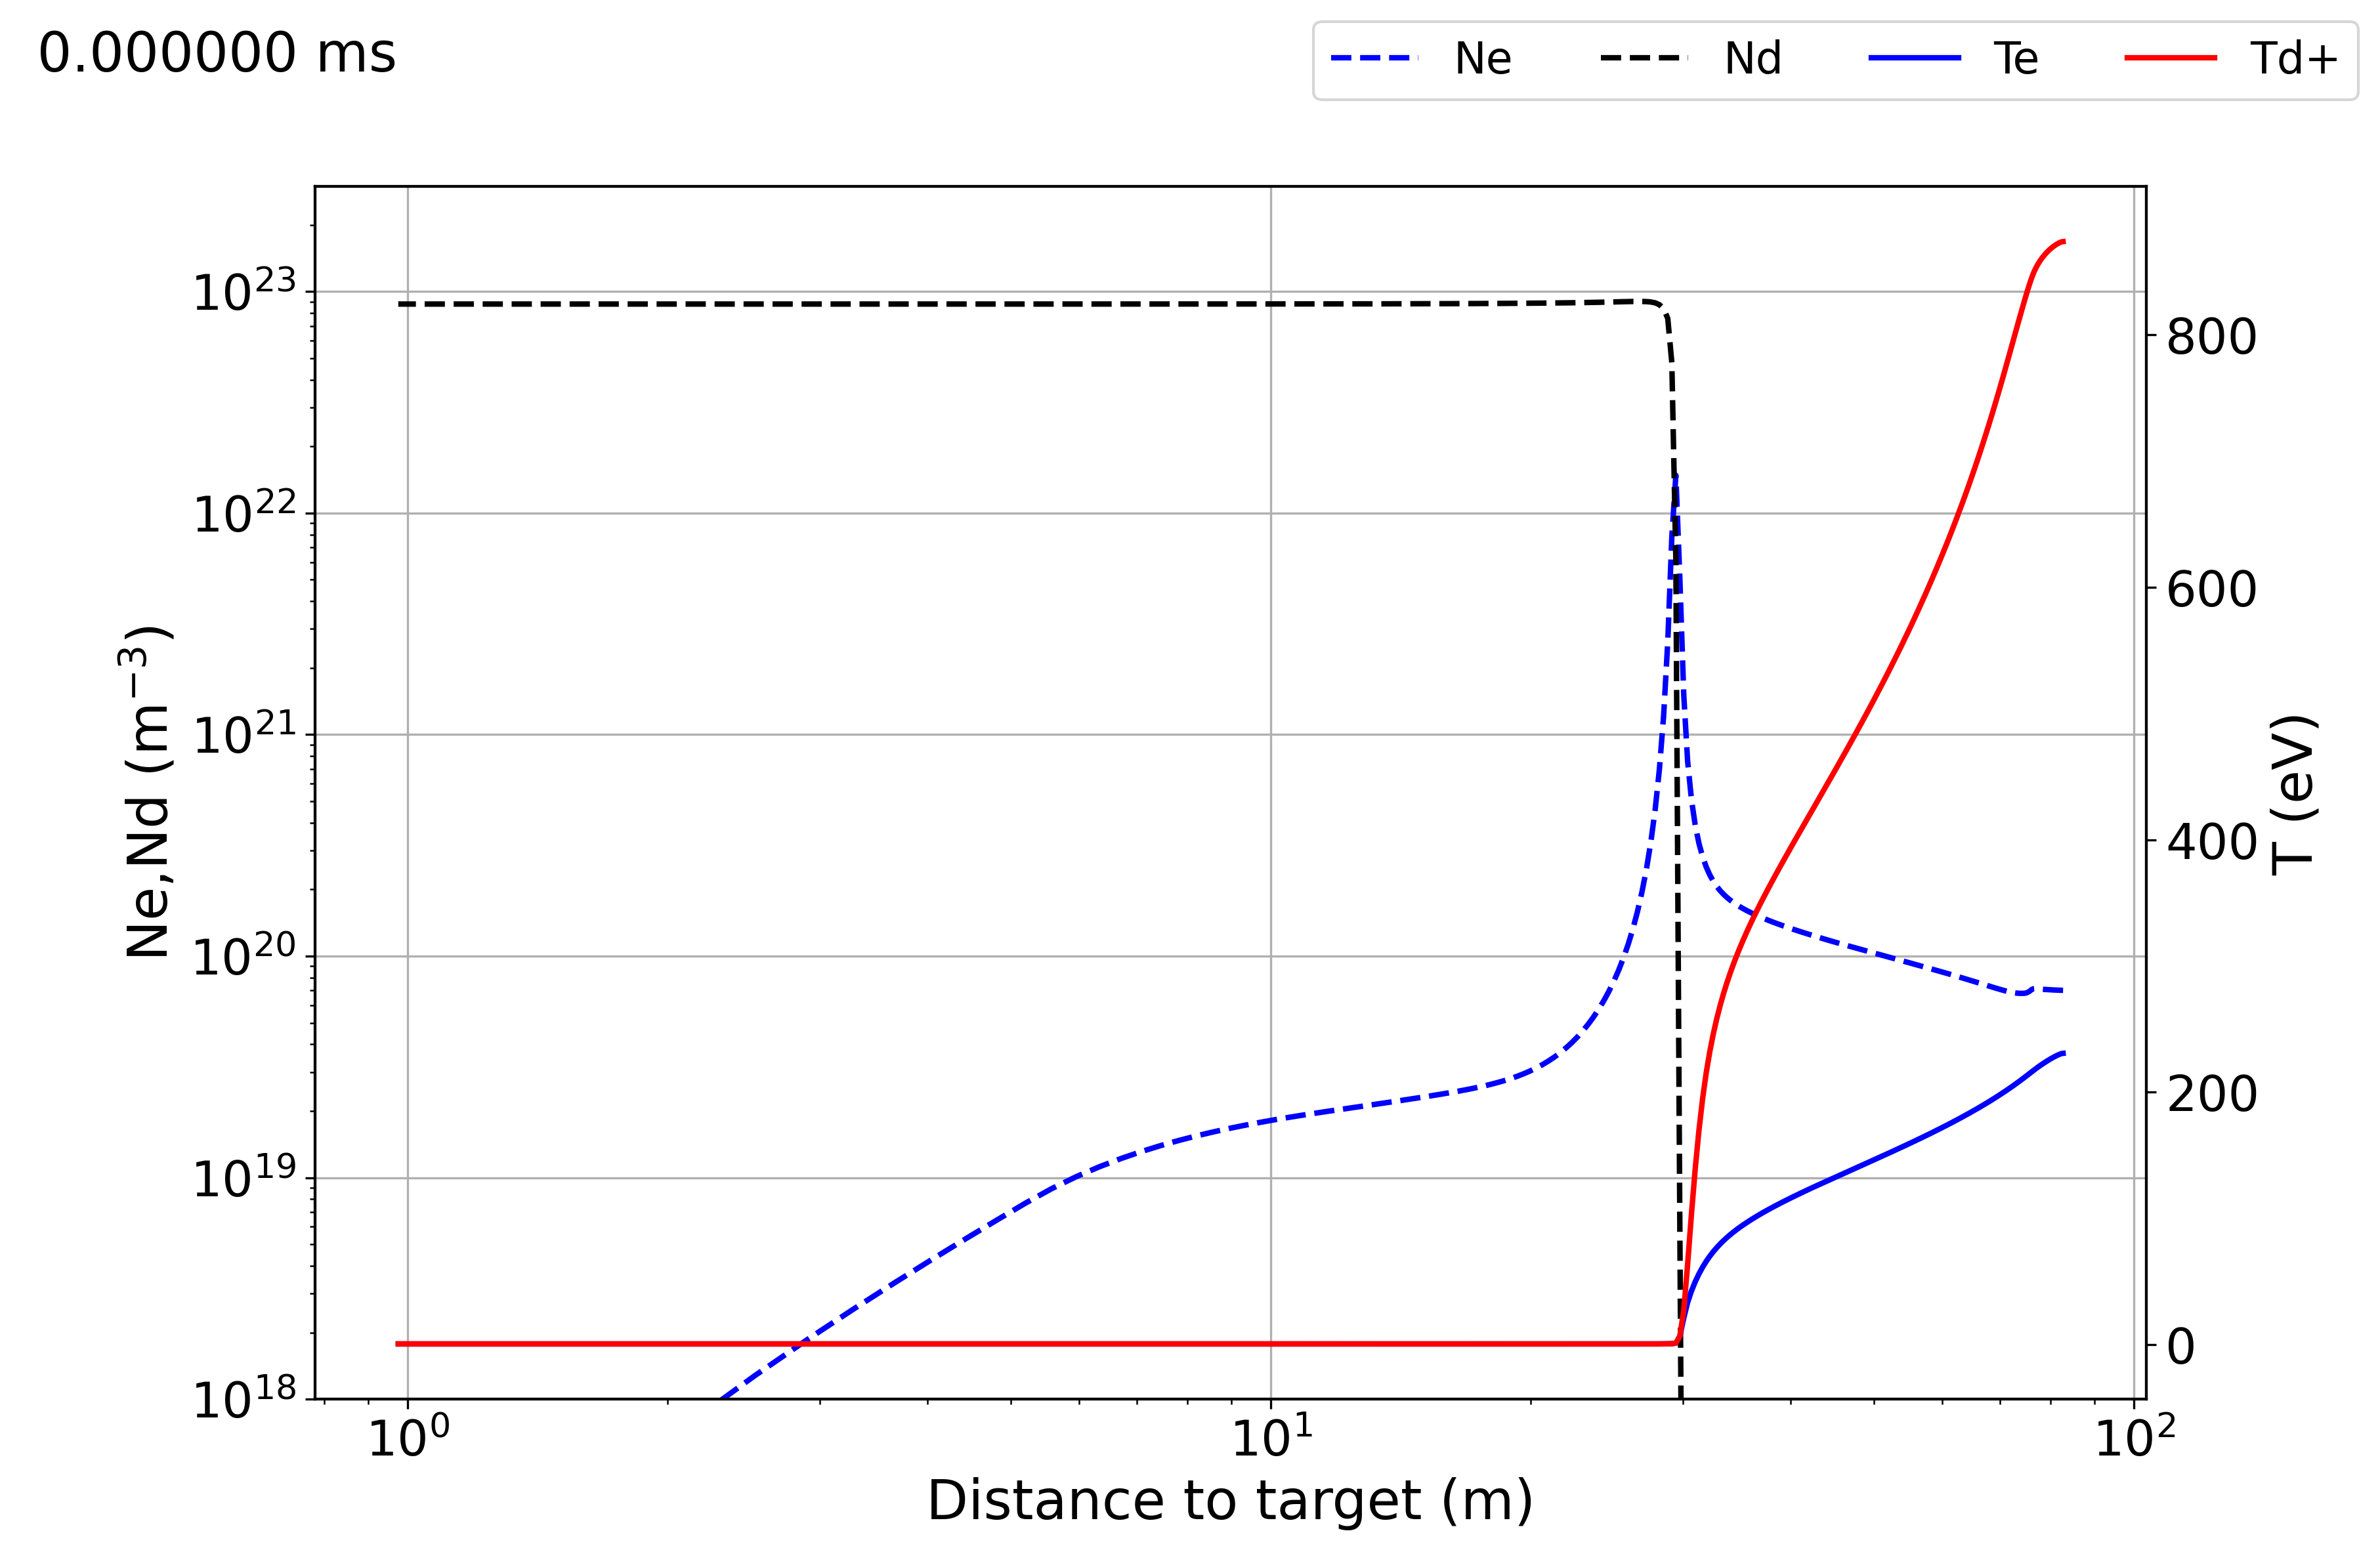

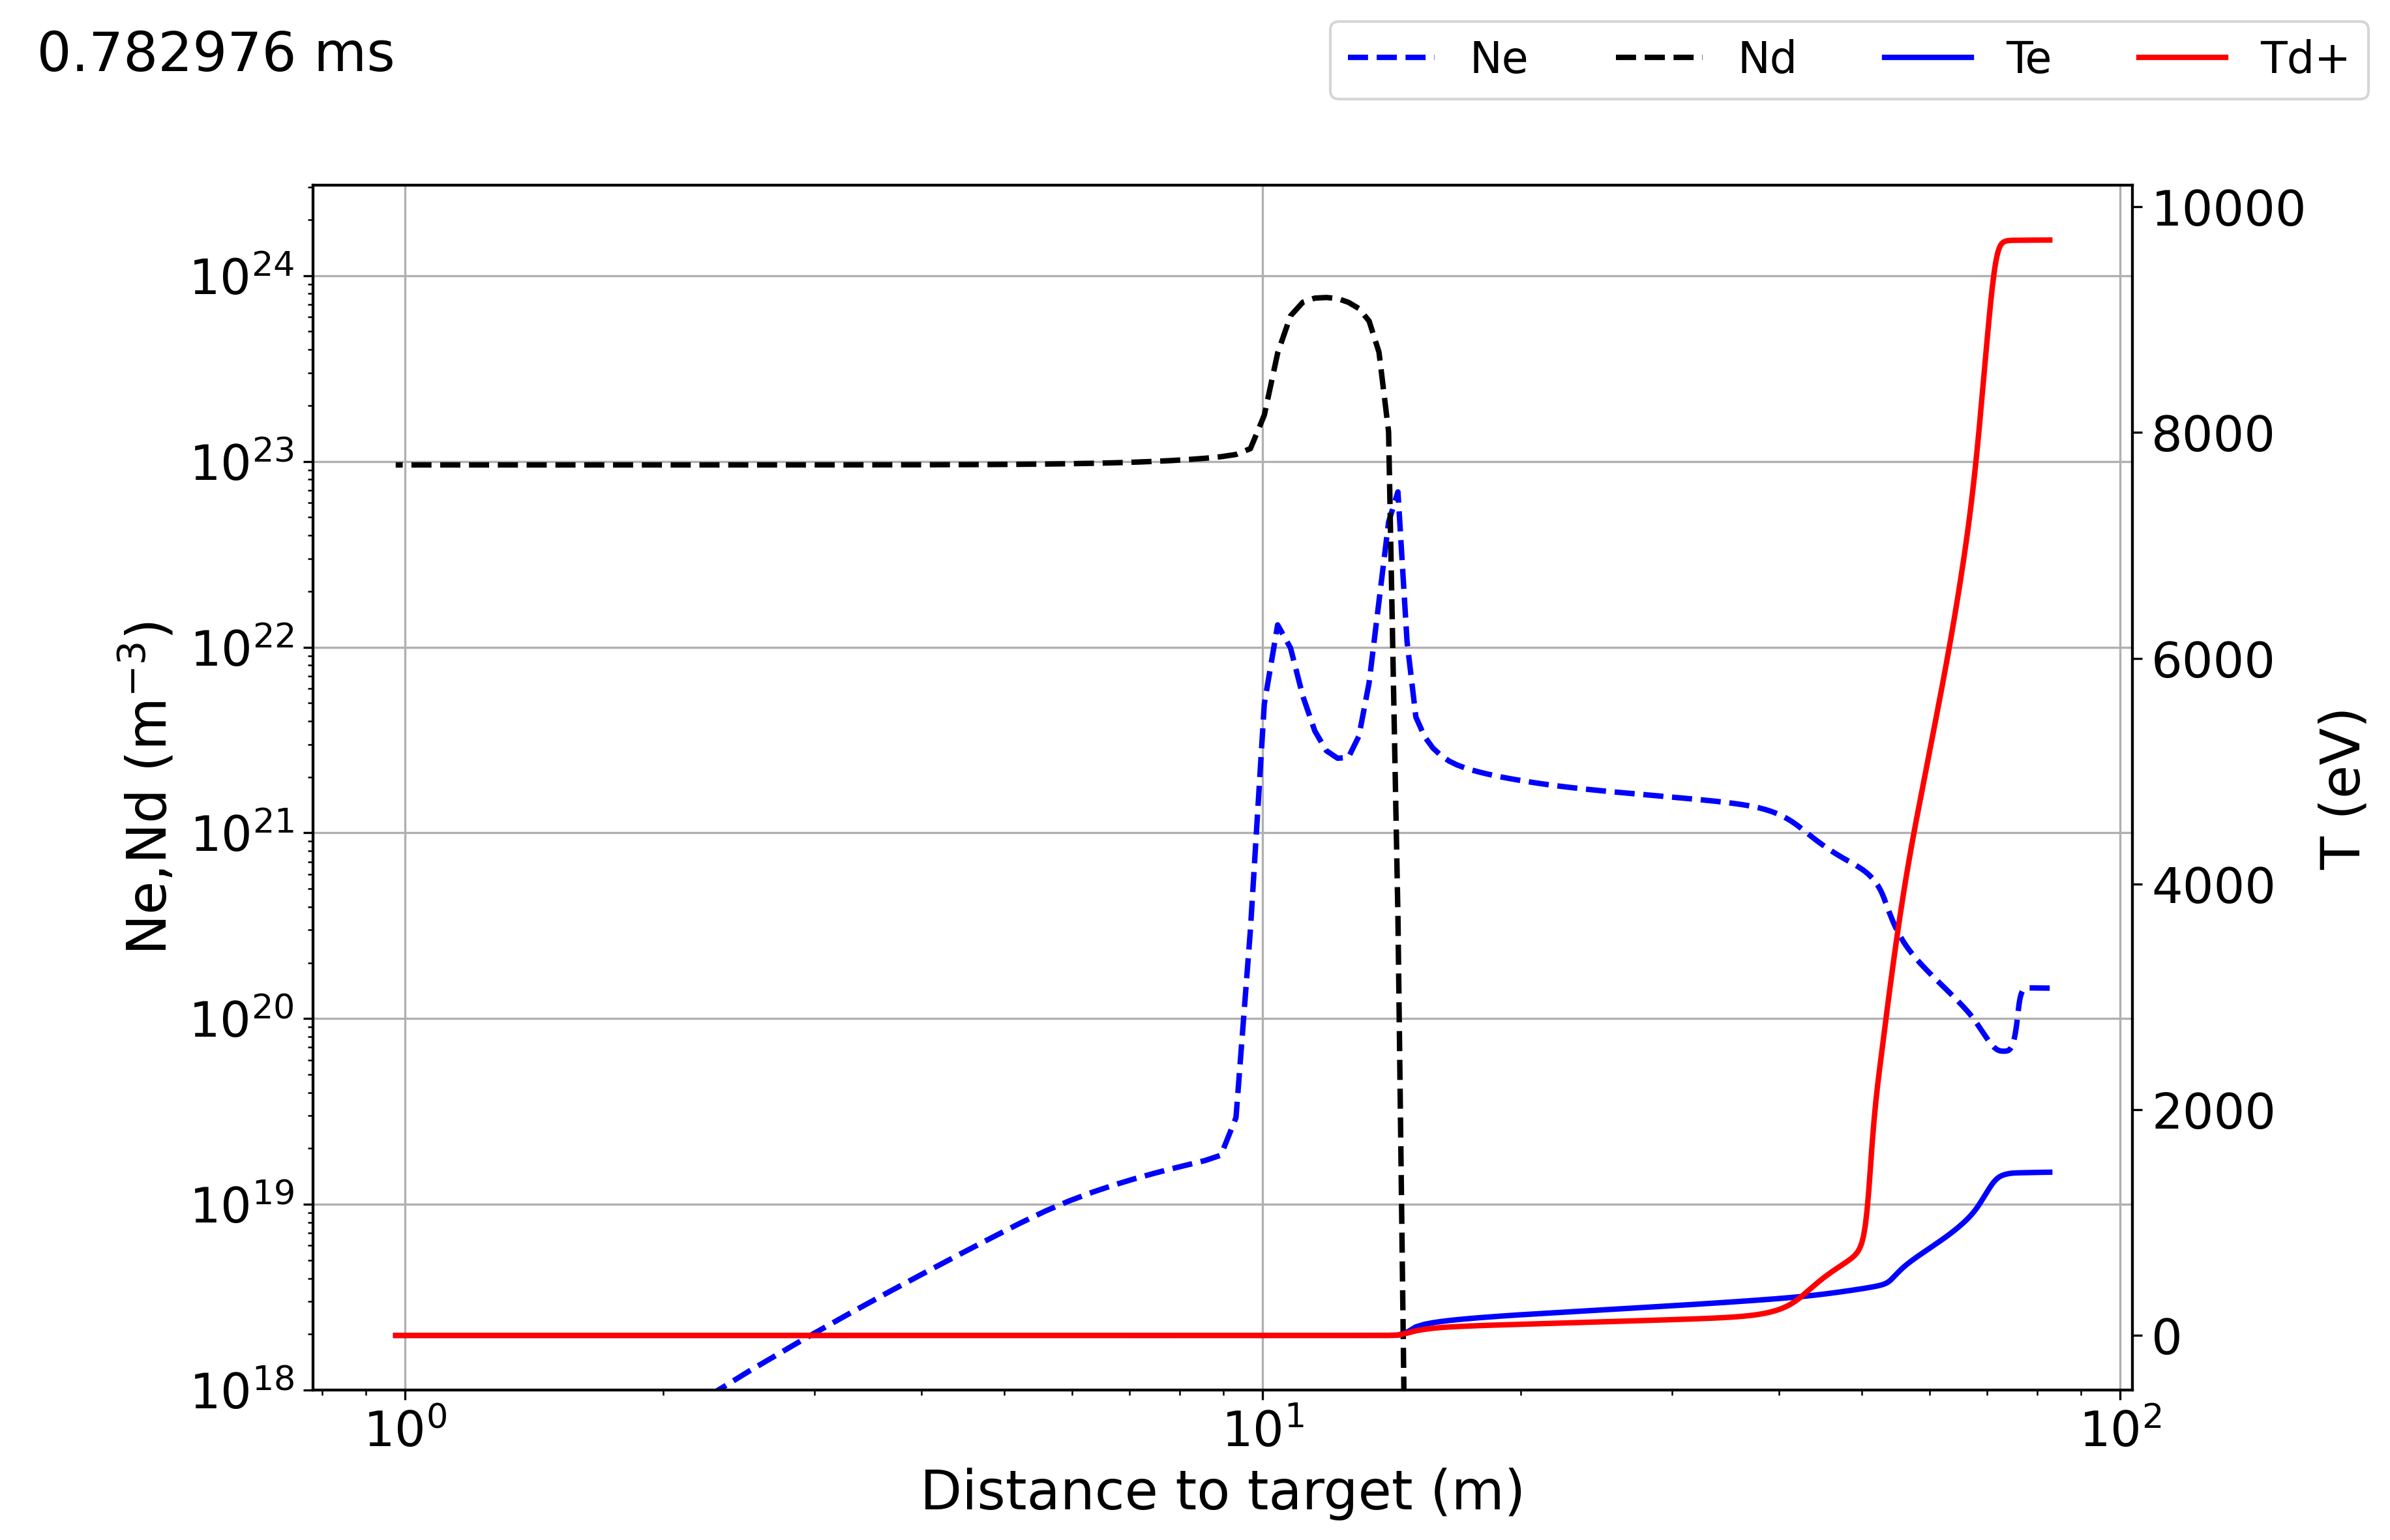

index  76


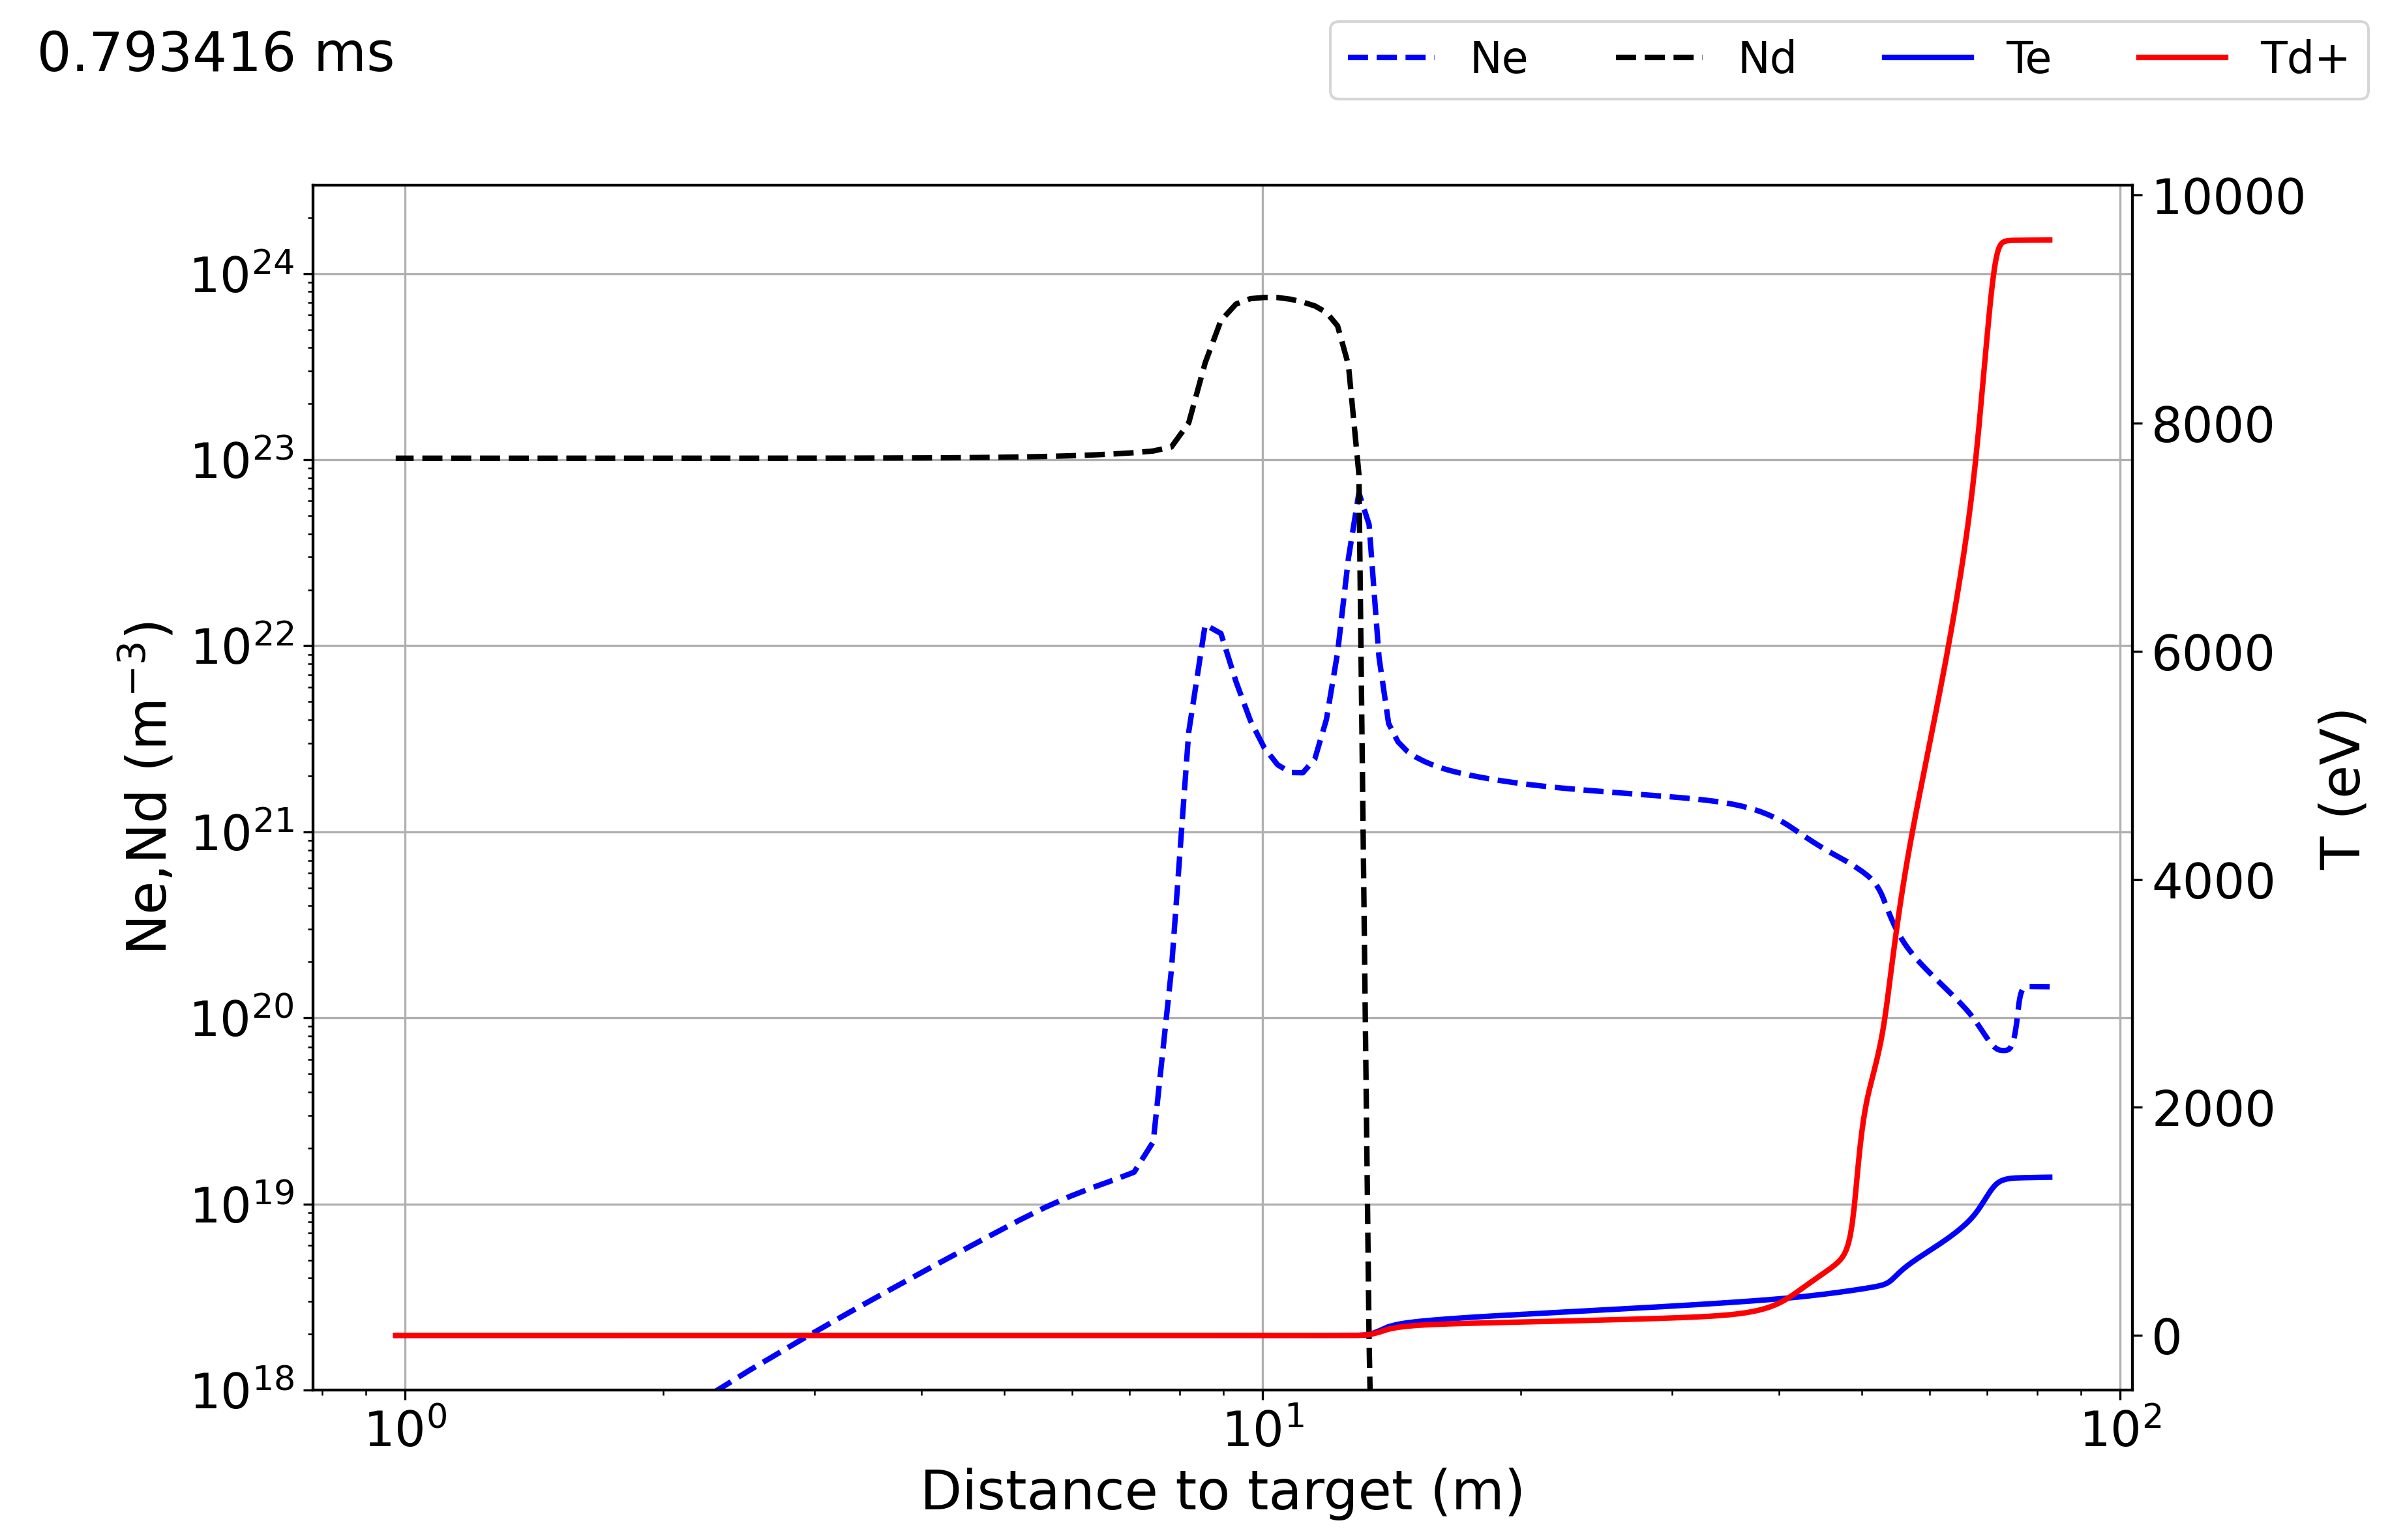

index  77


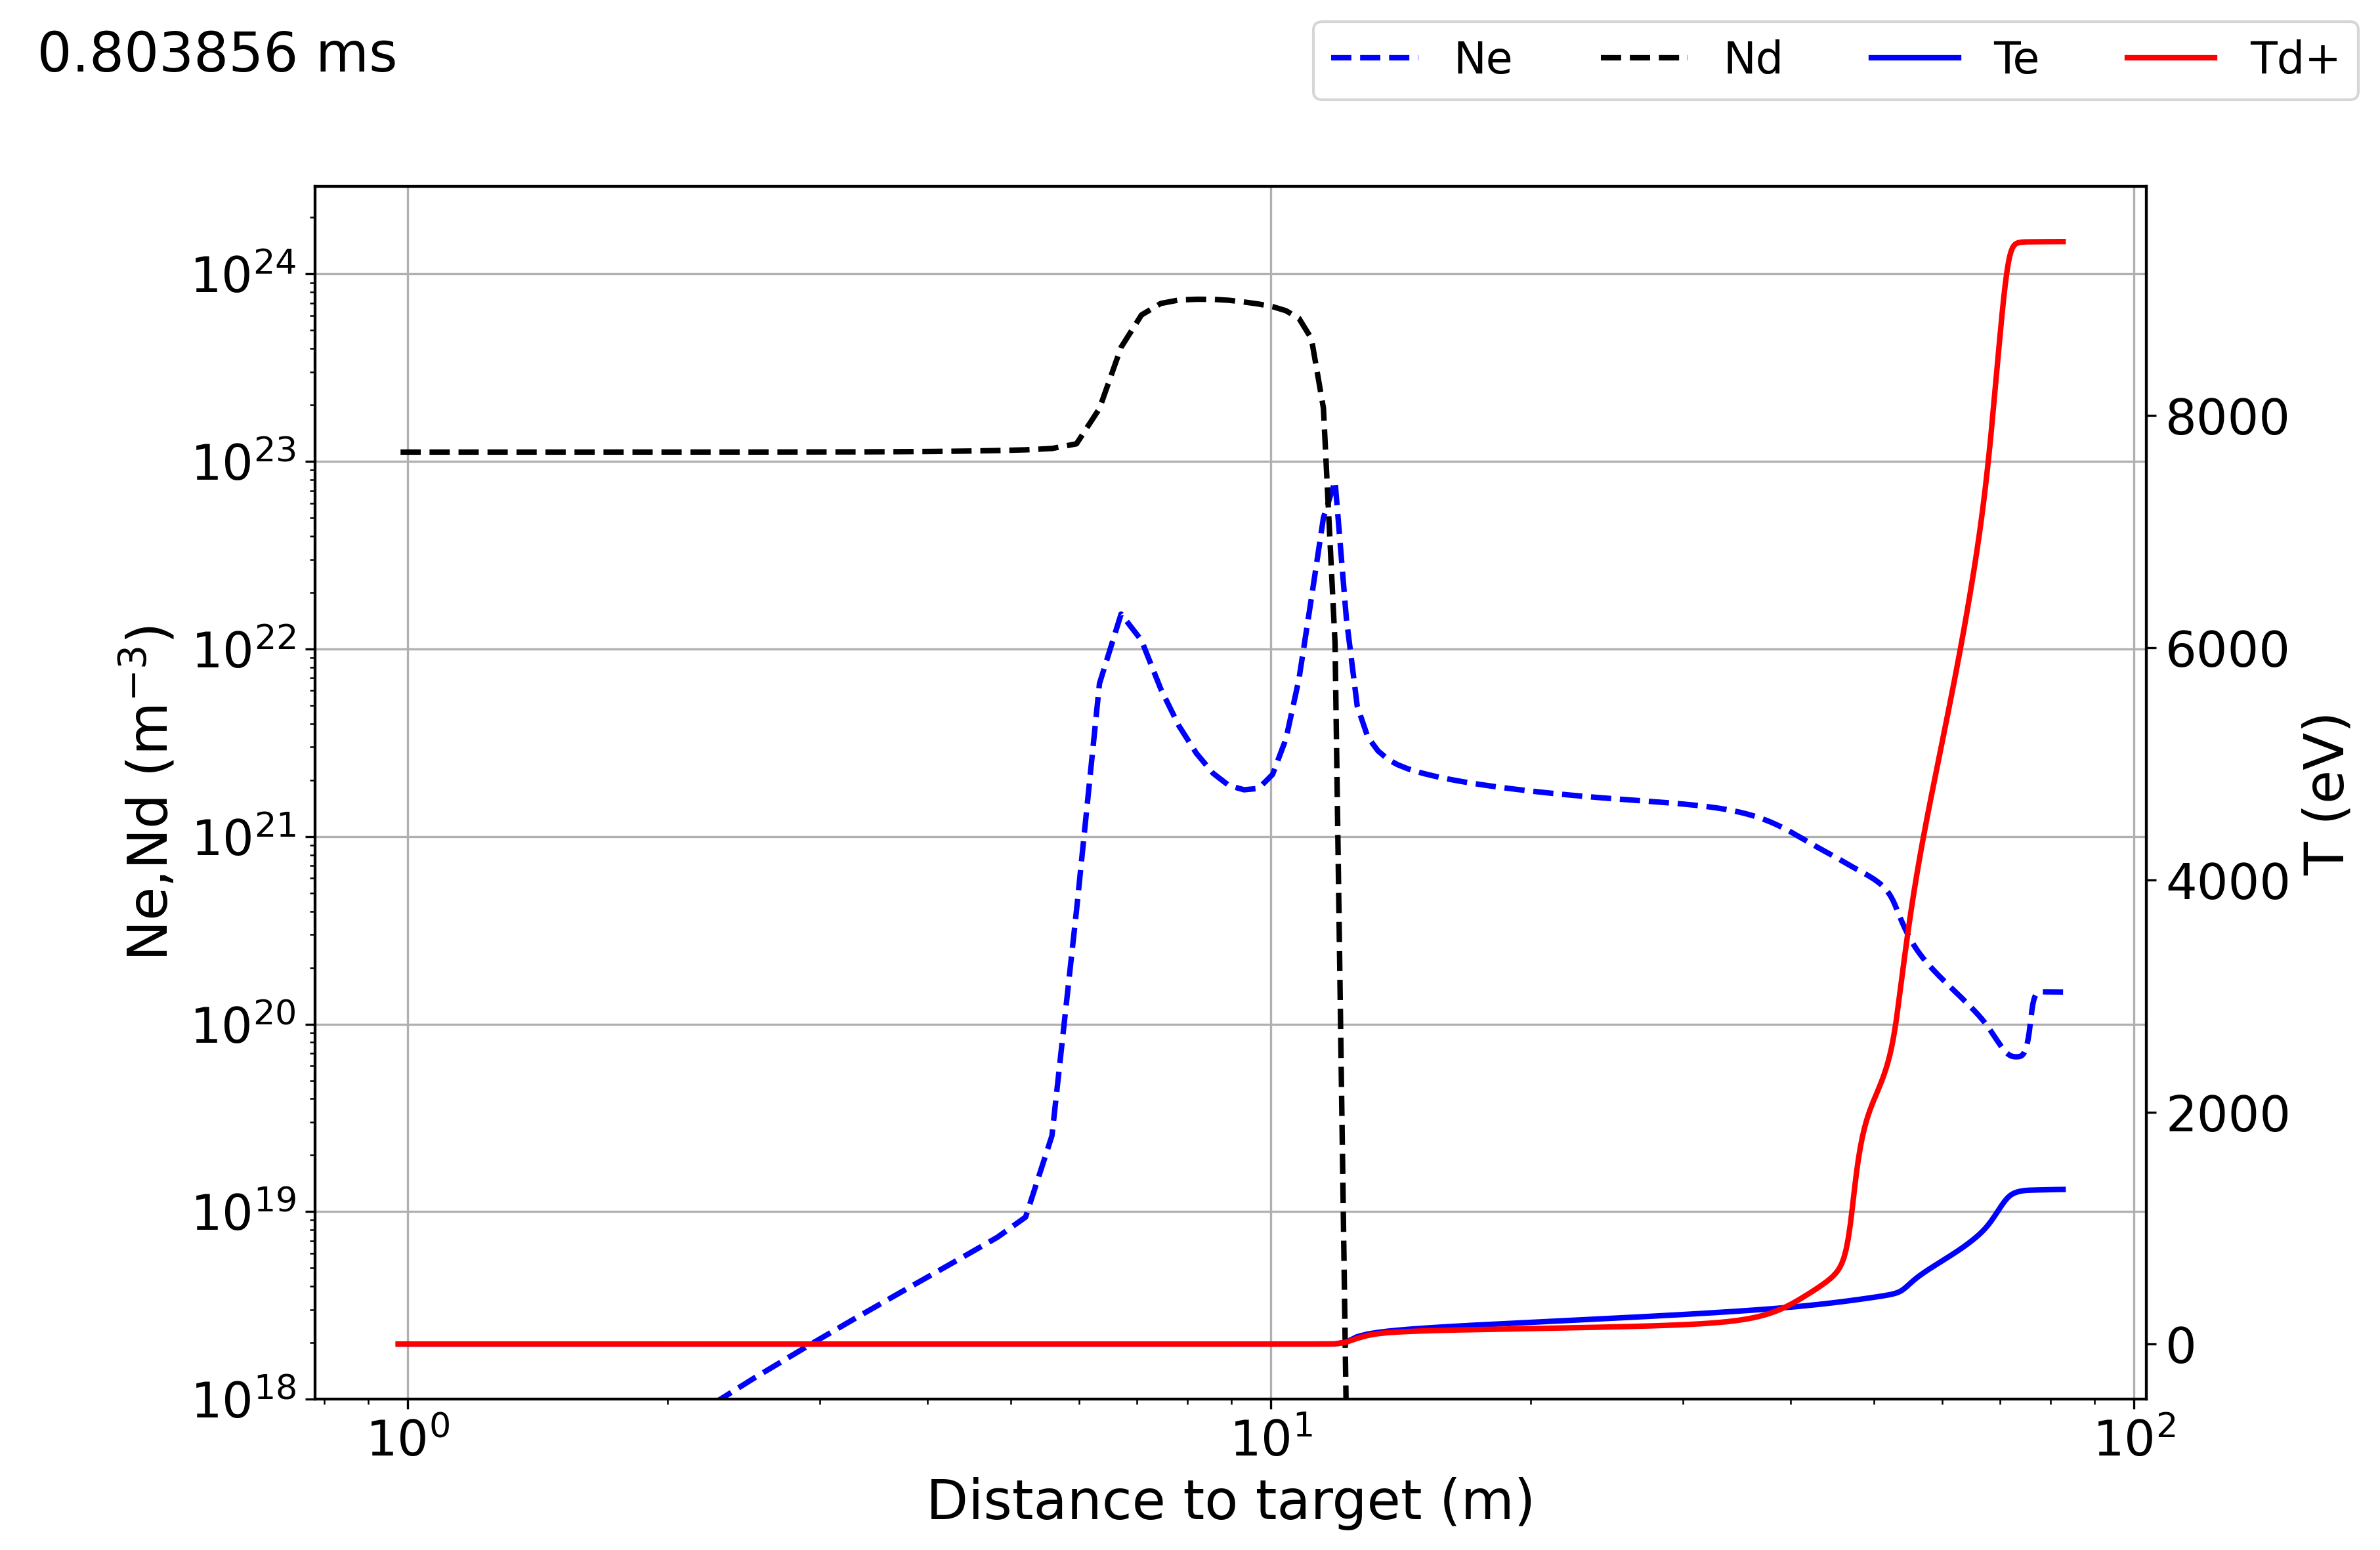

index  78


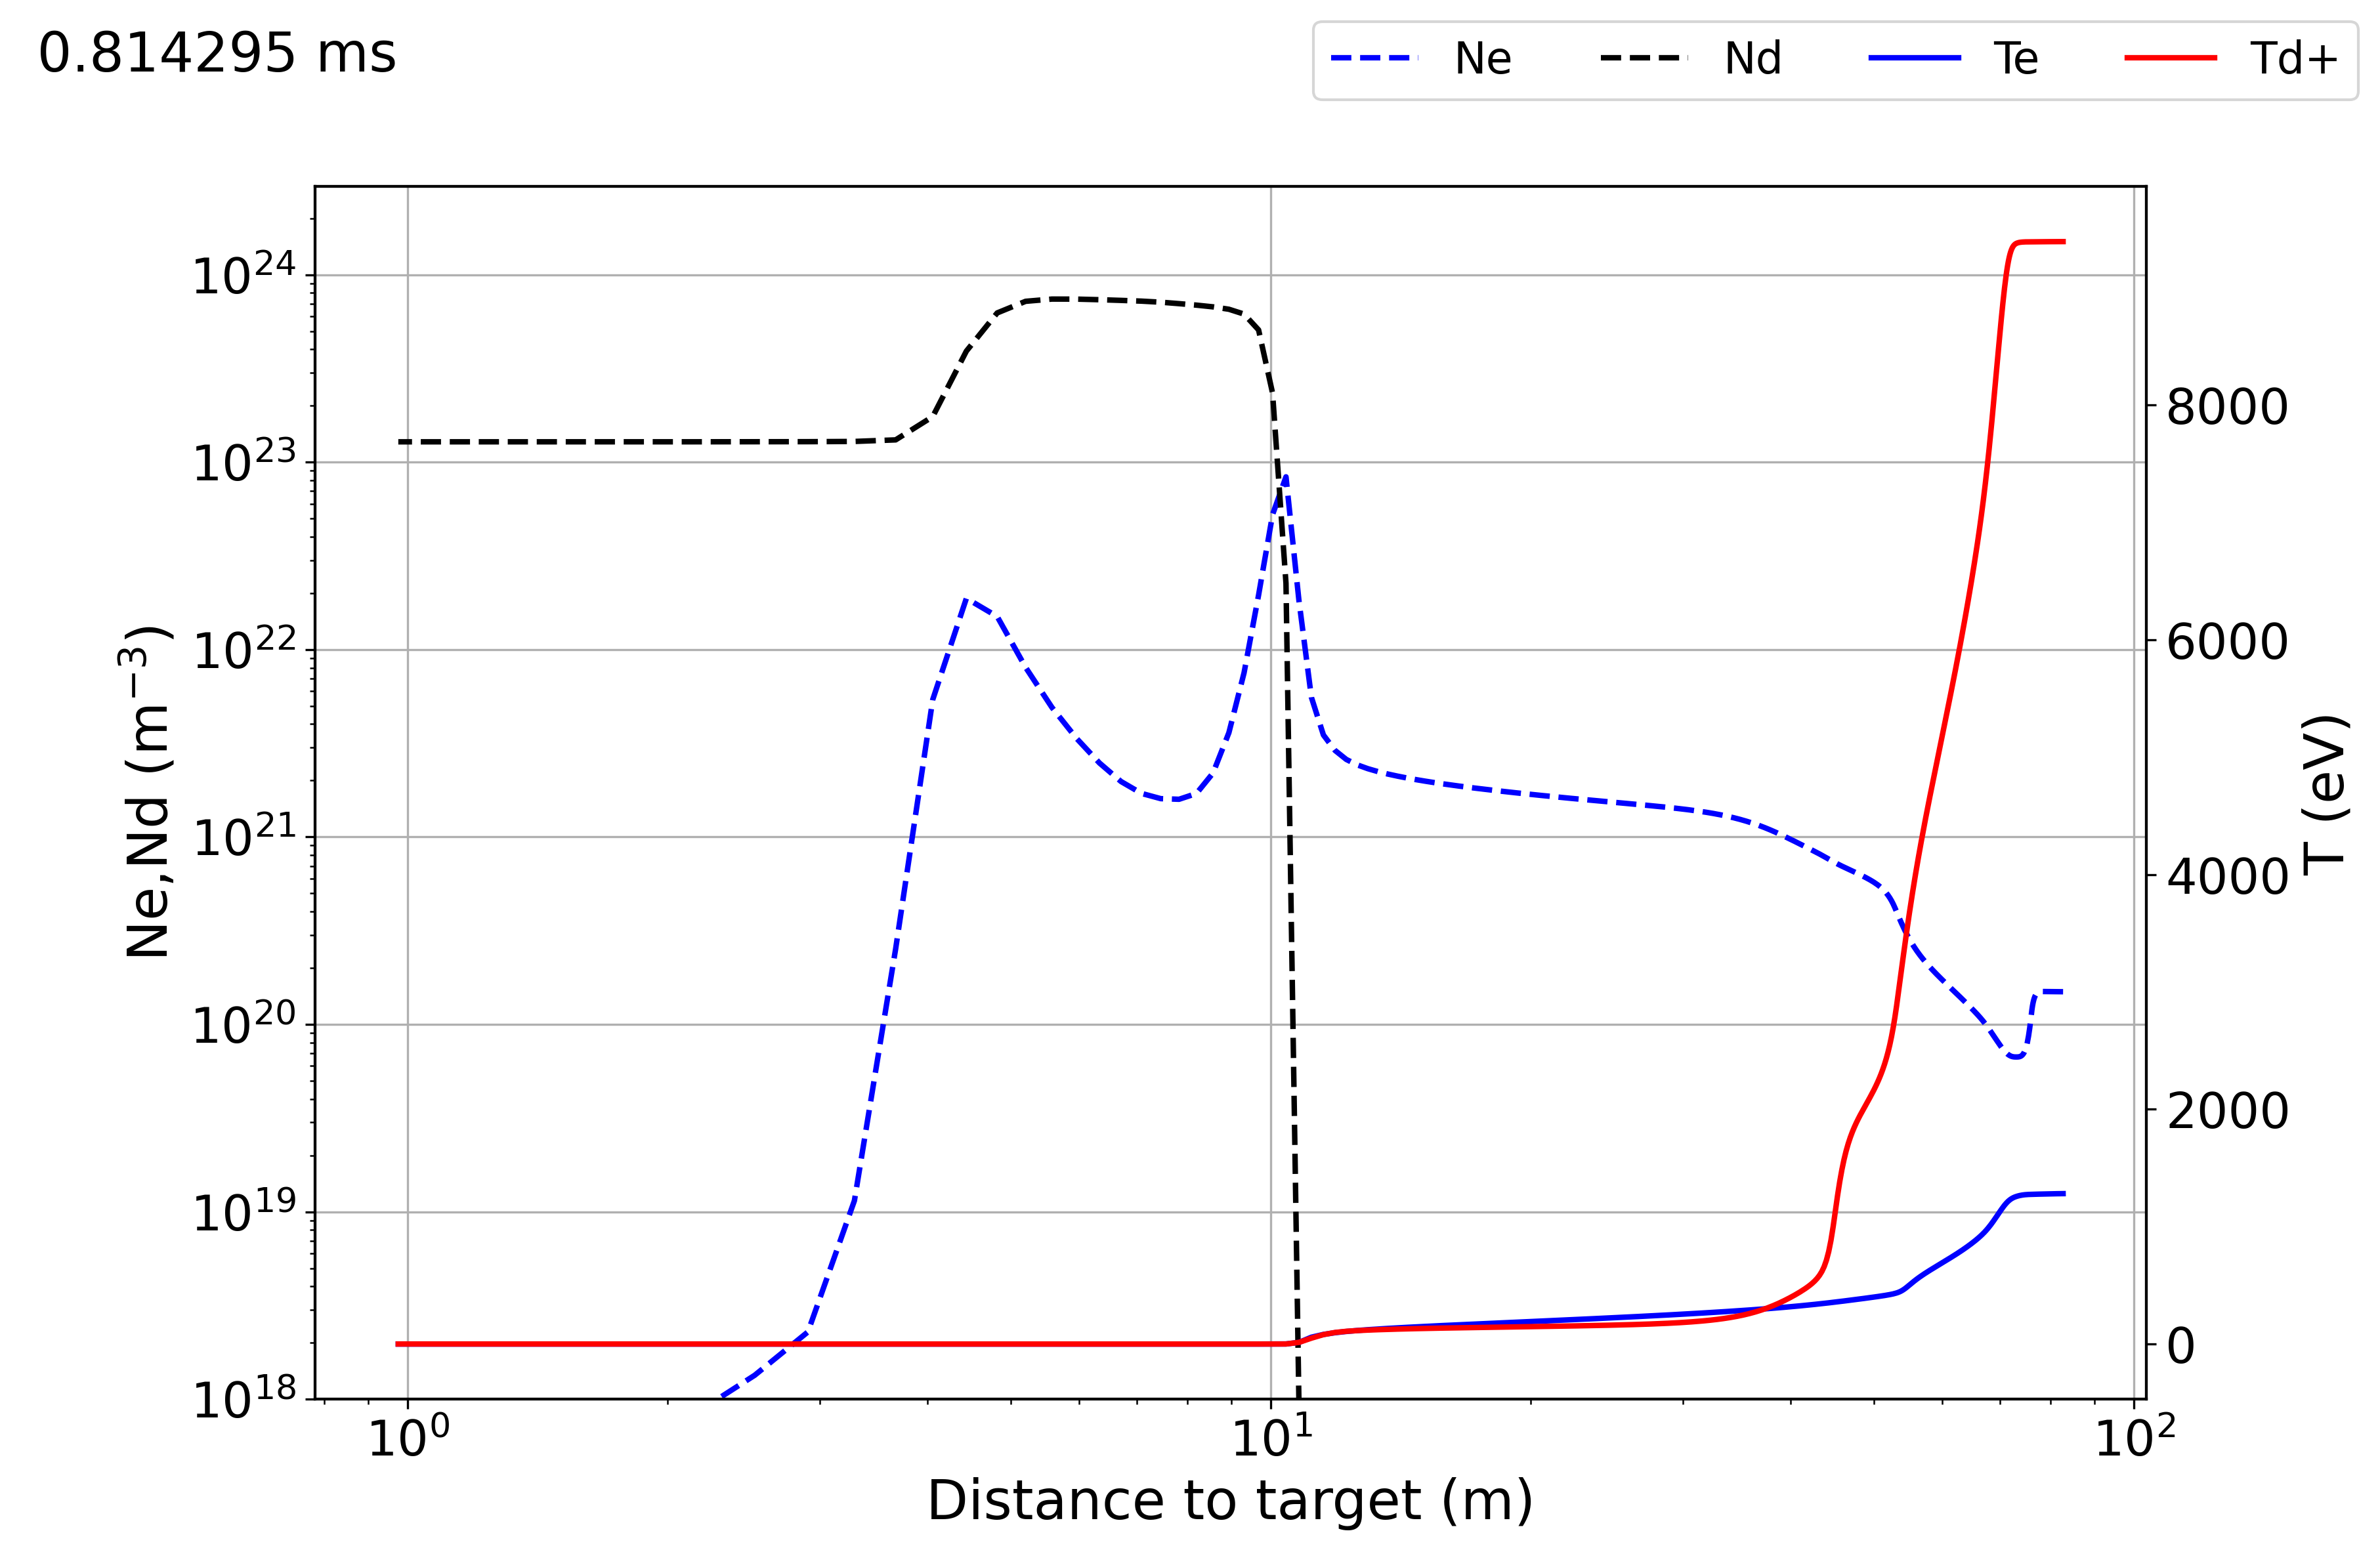

index  79


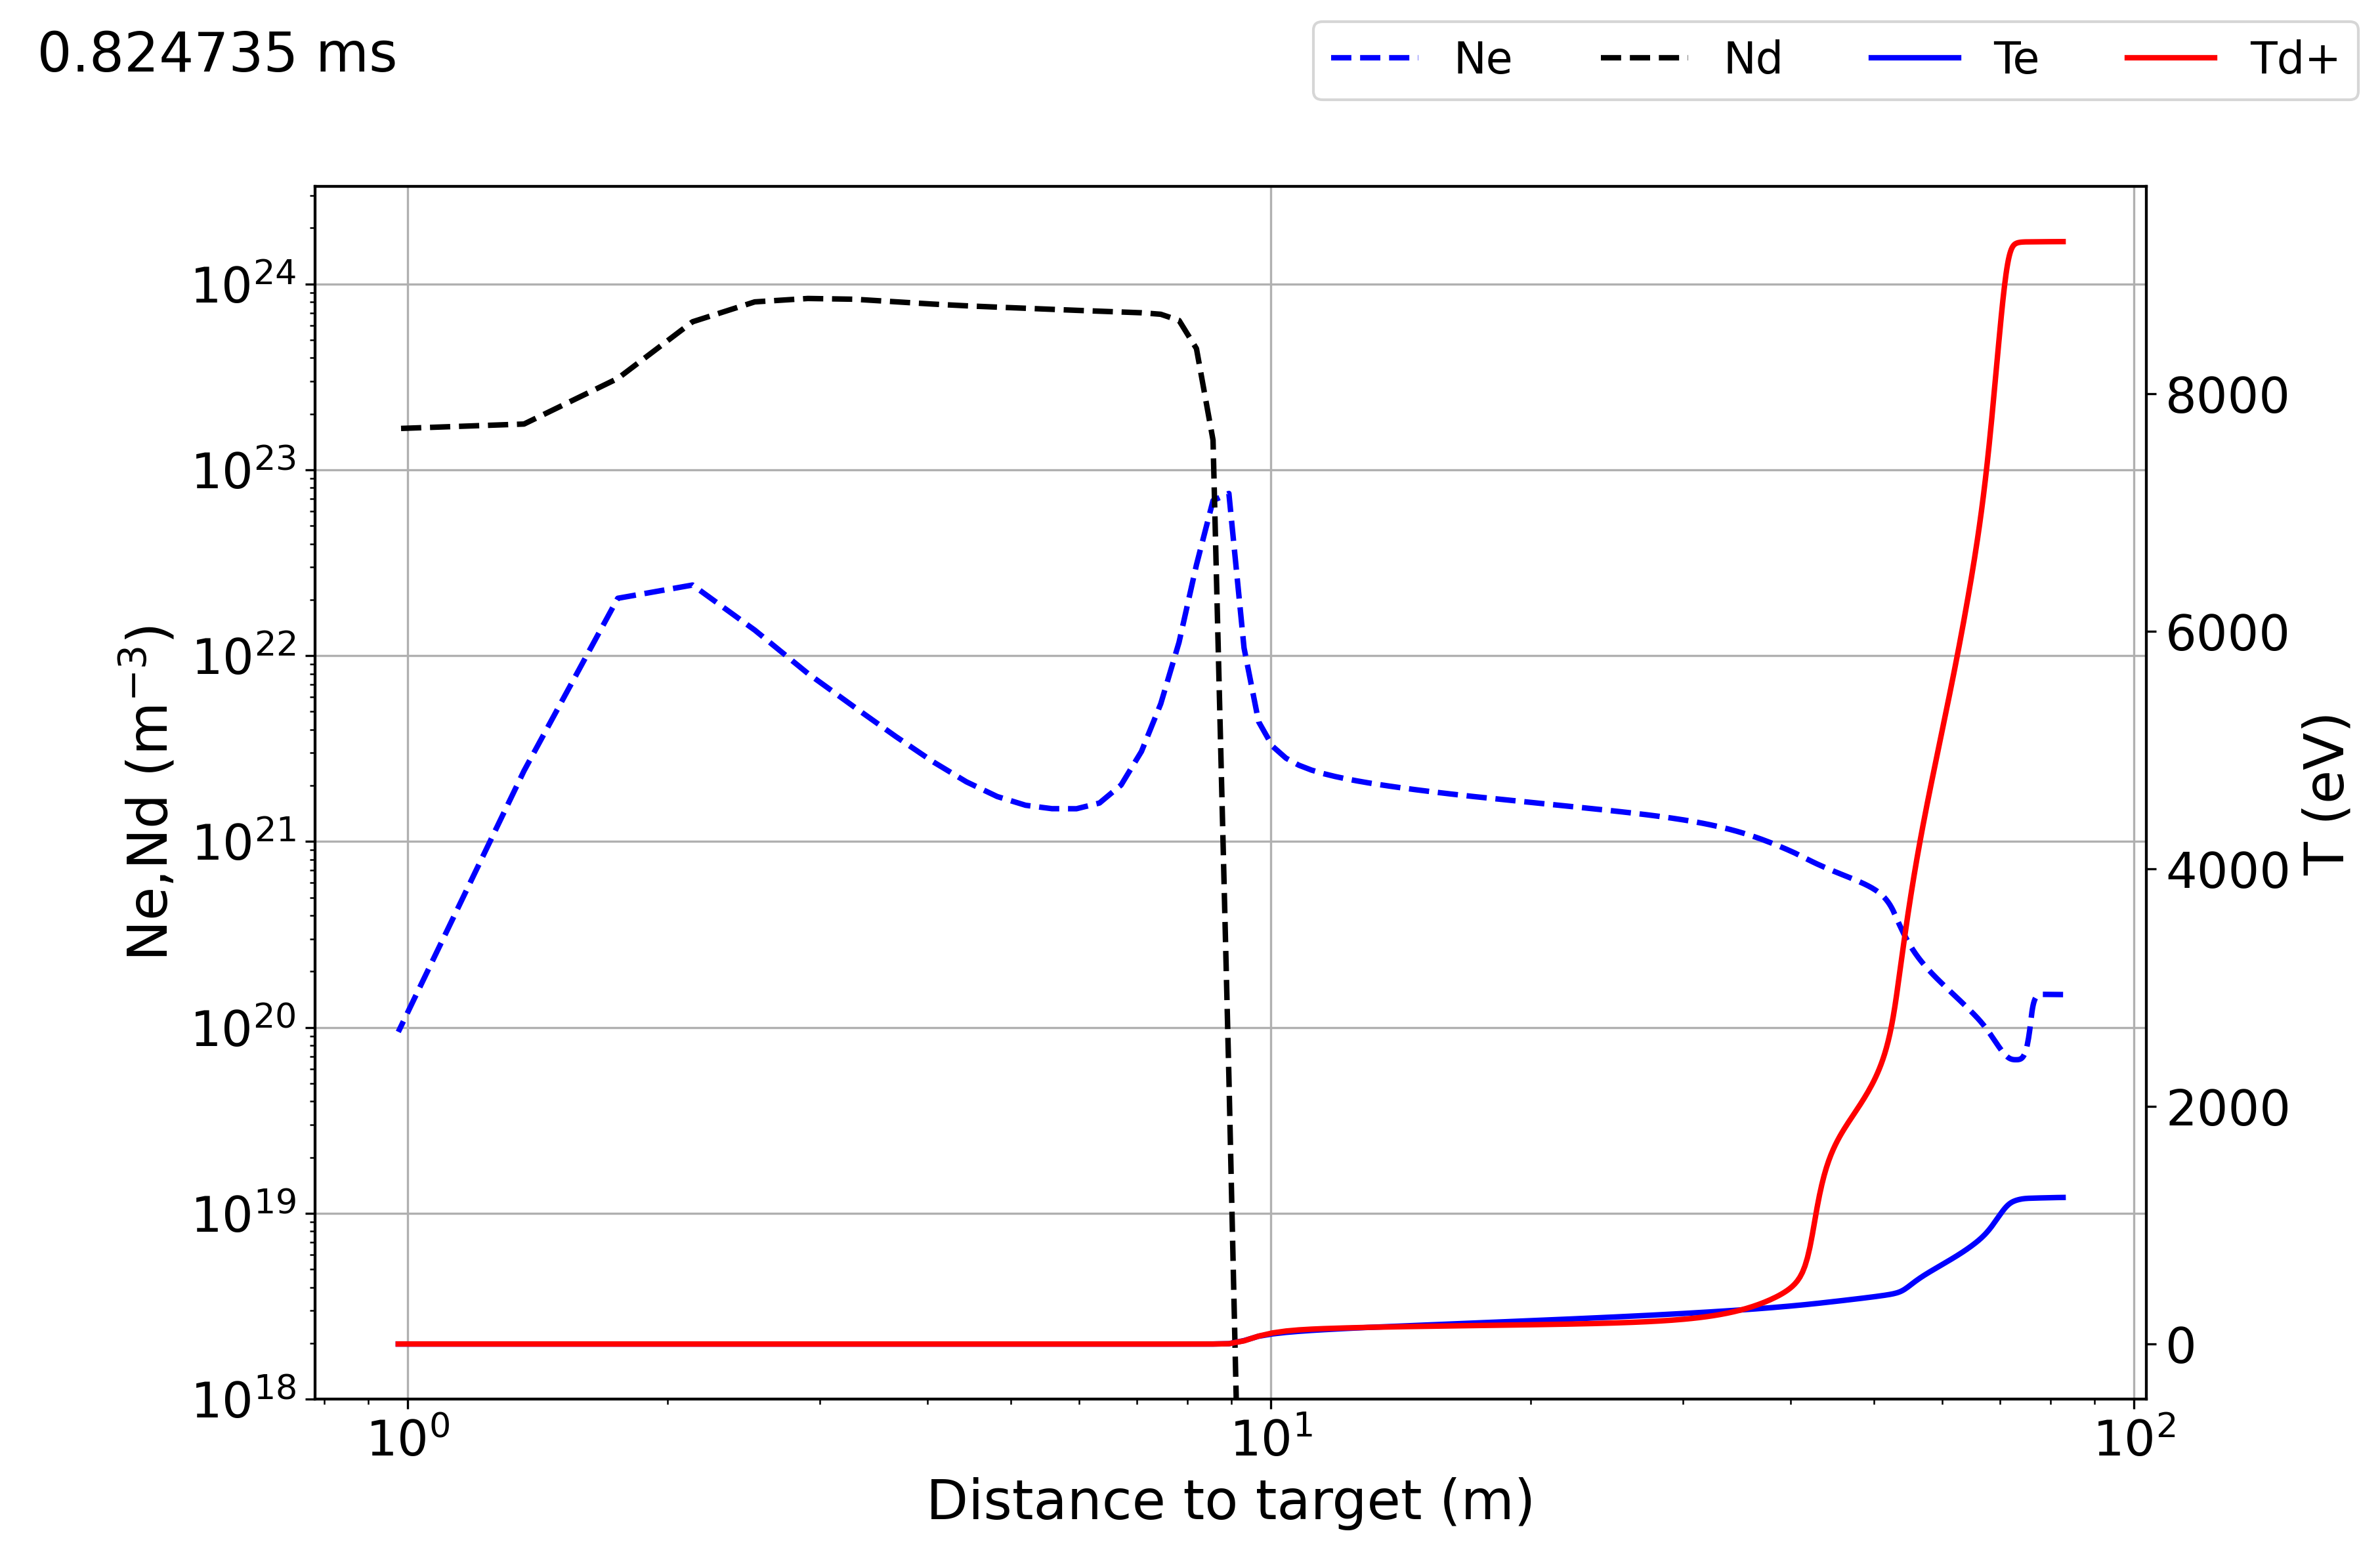

index  80


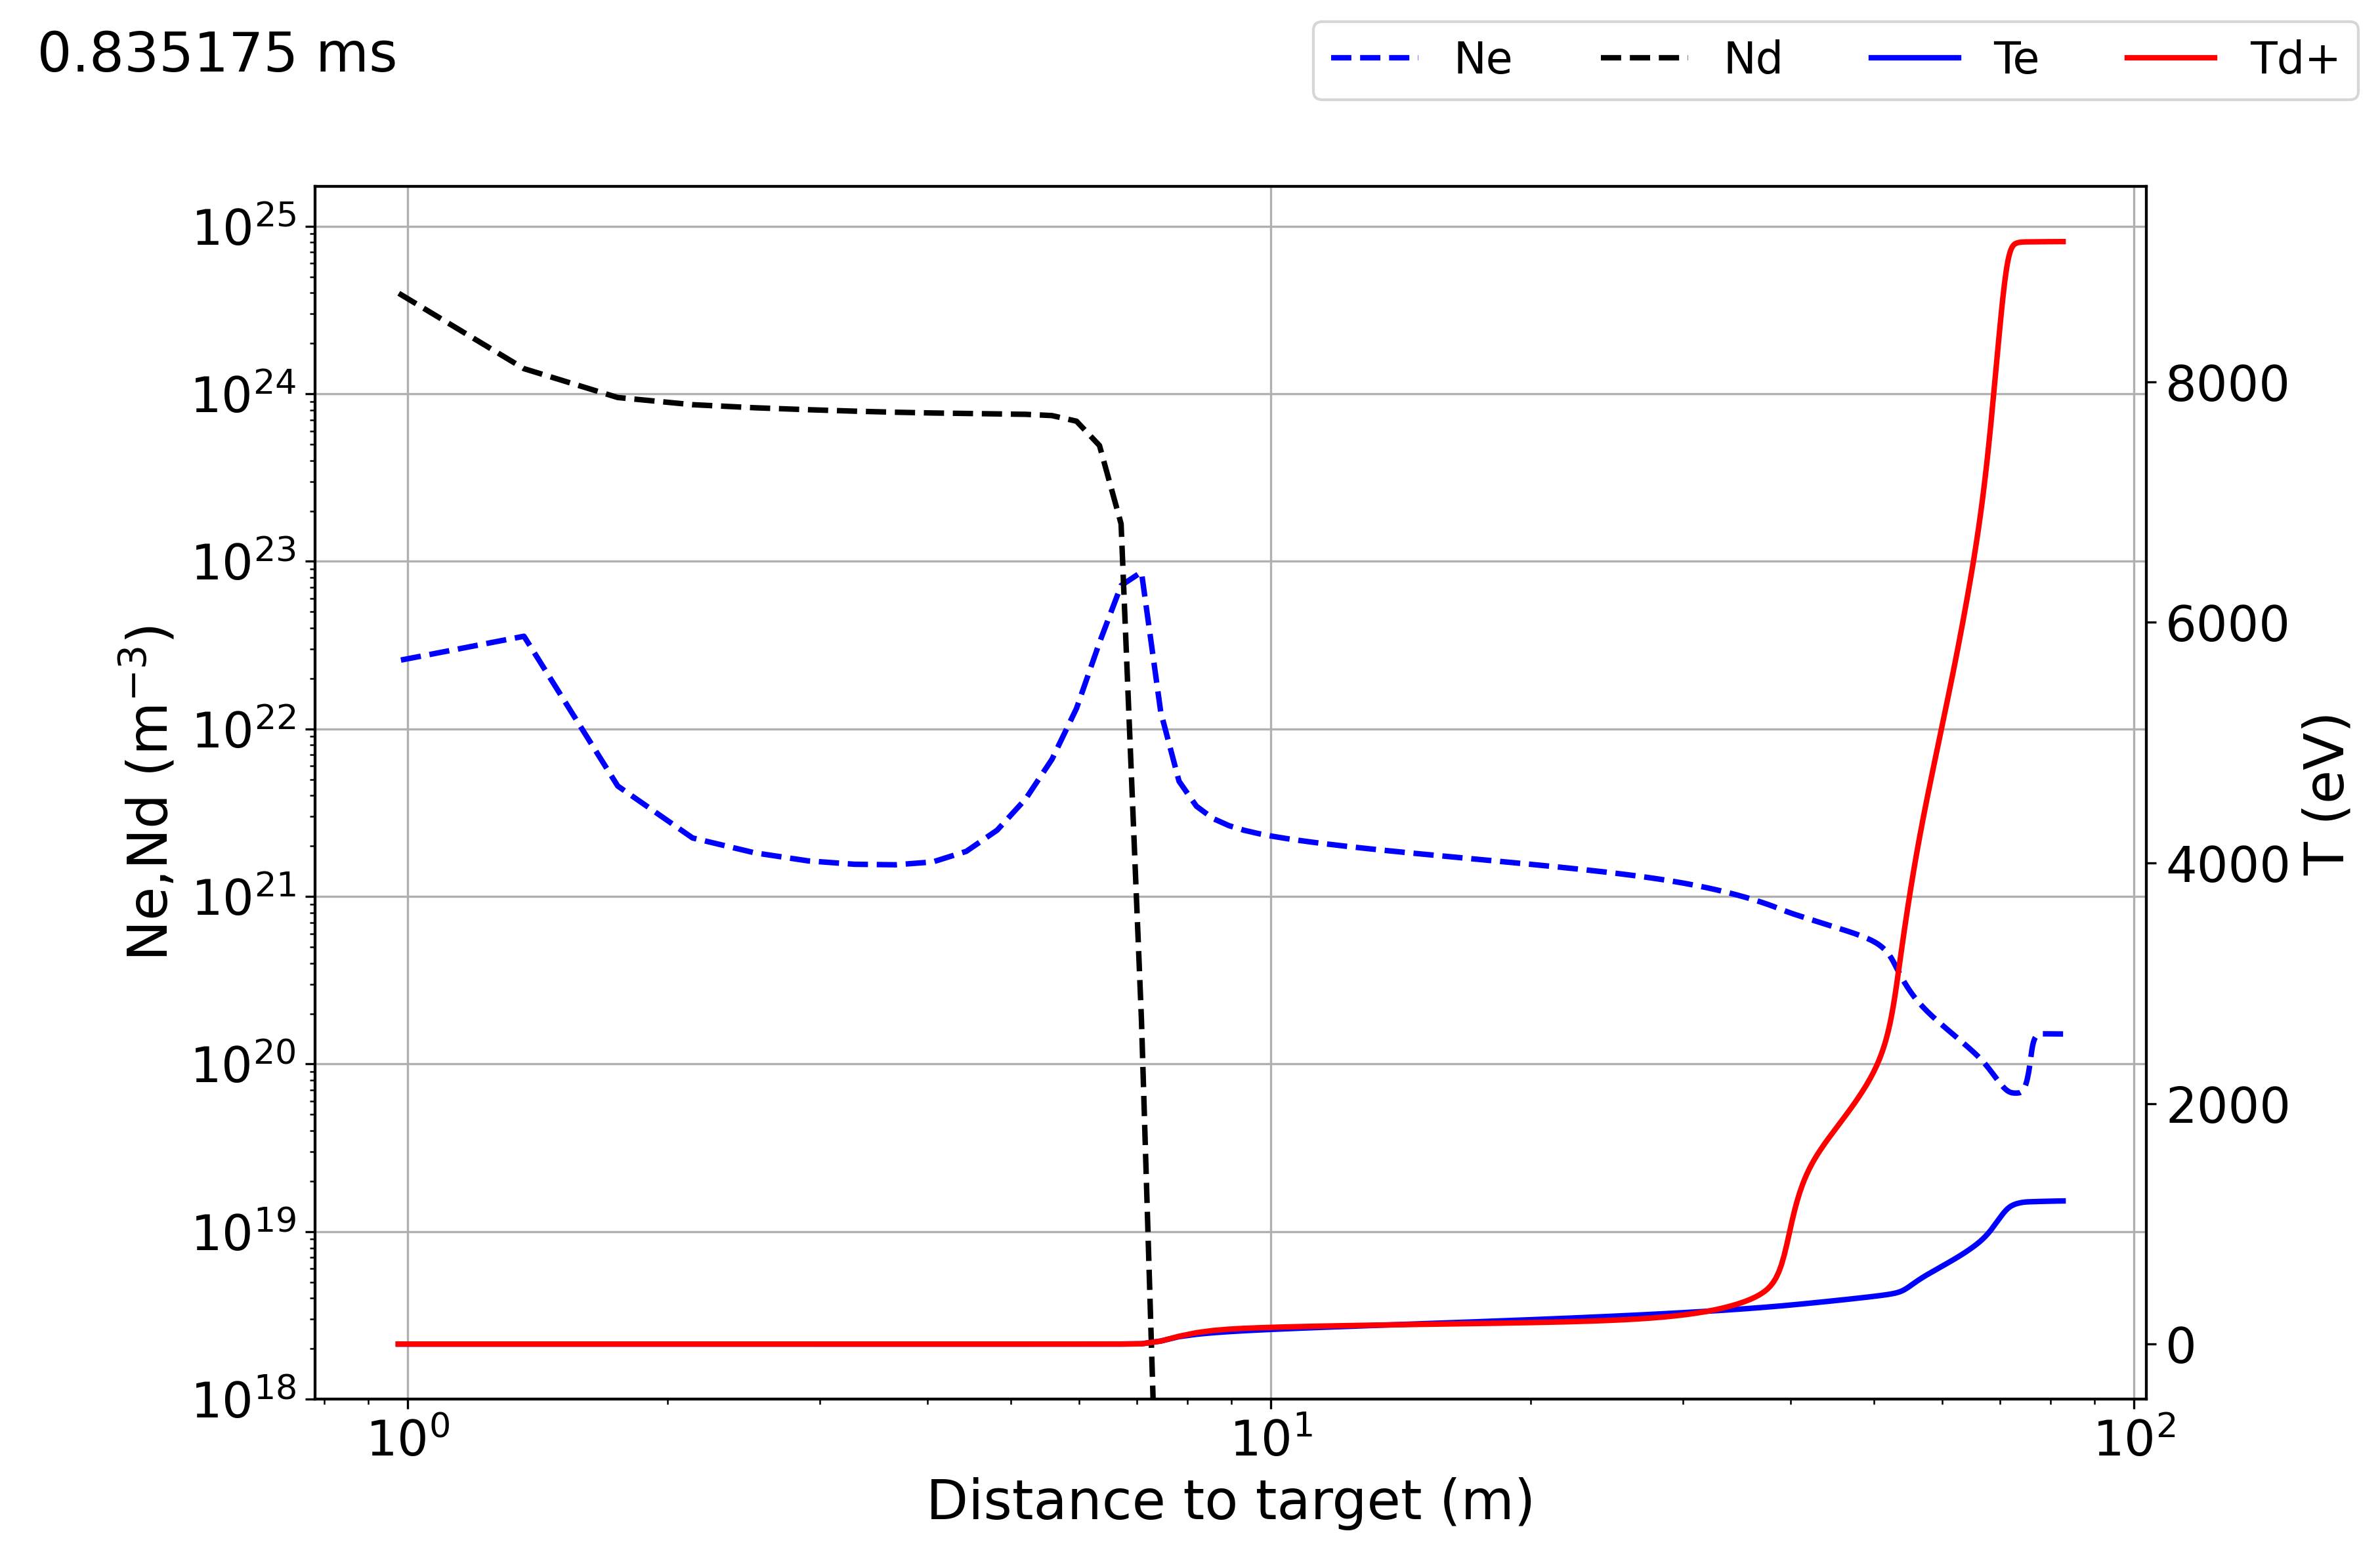

index  81


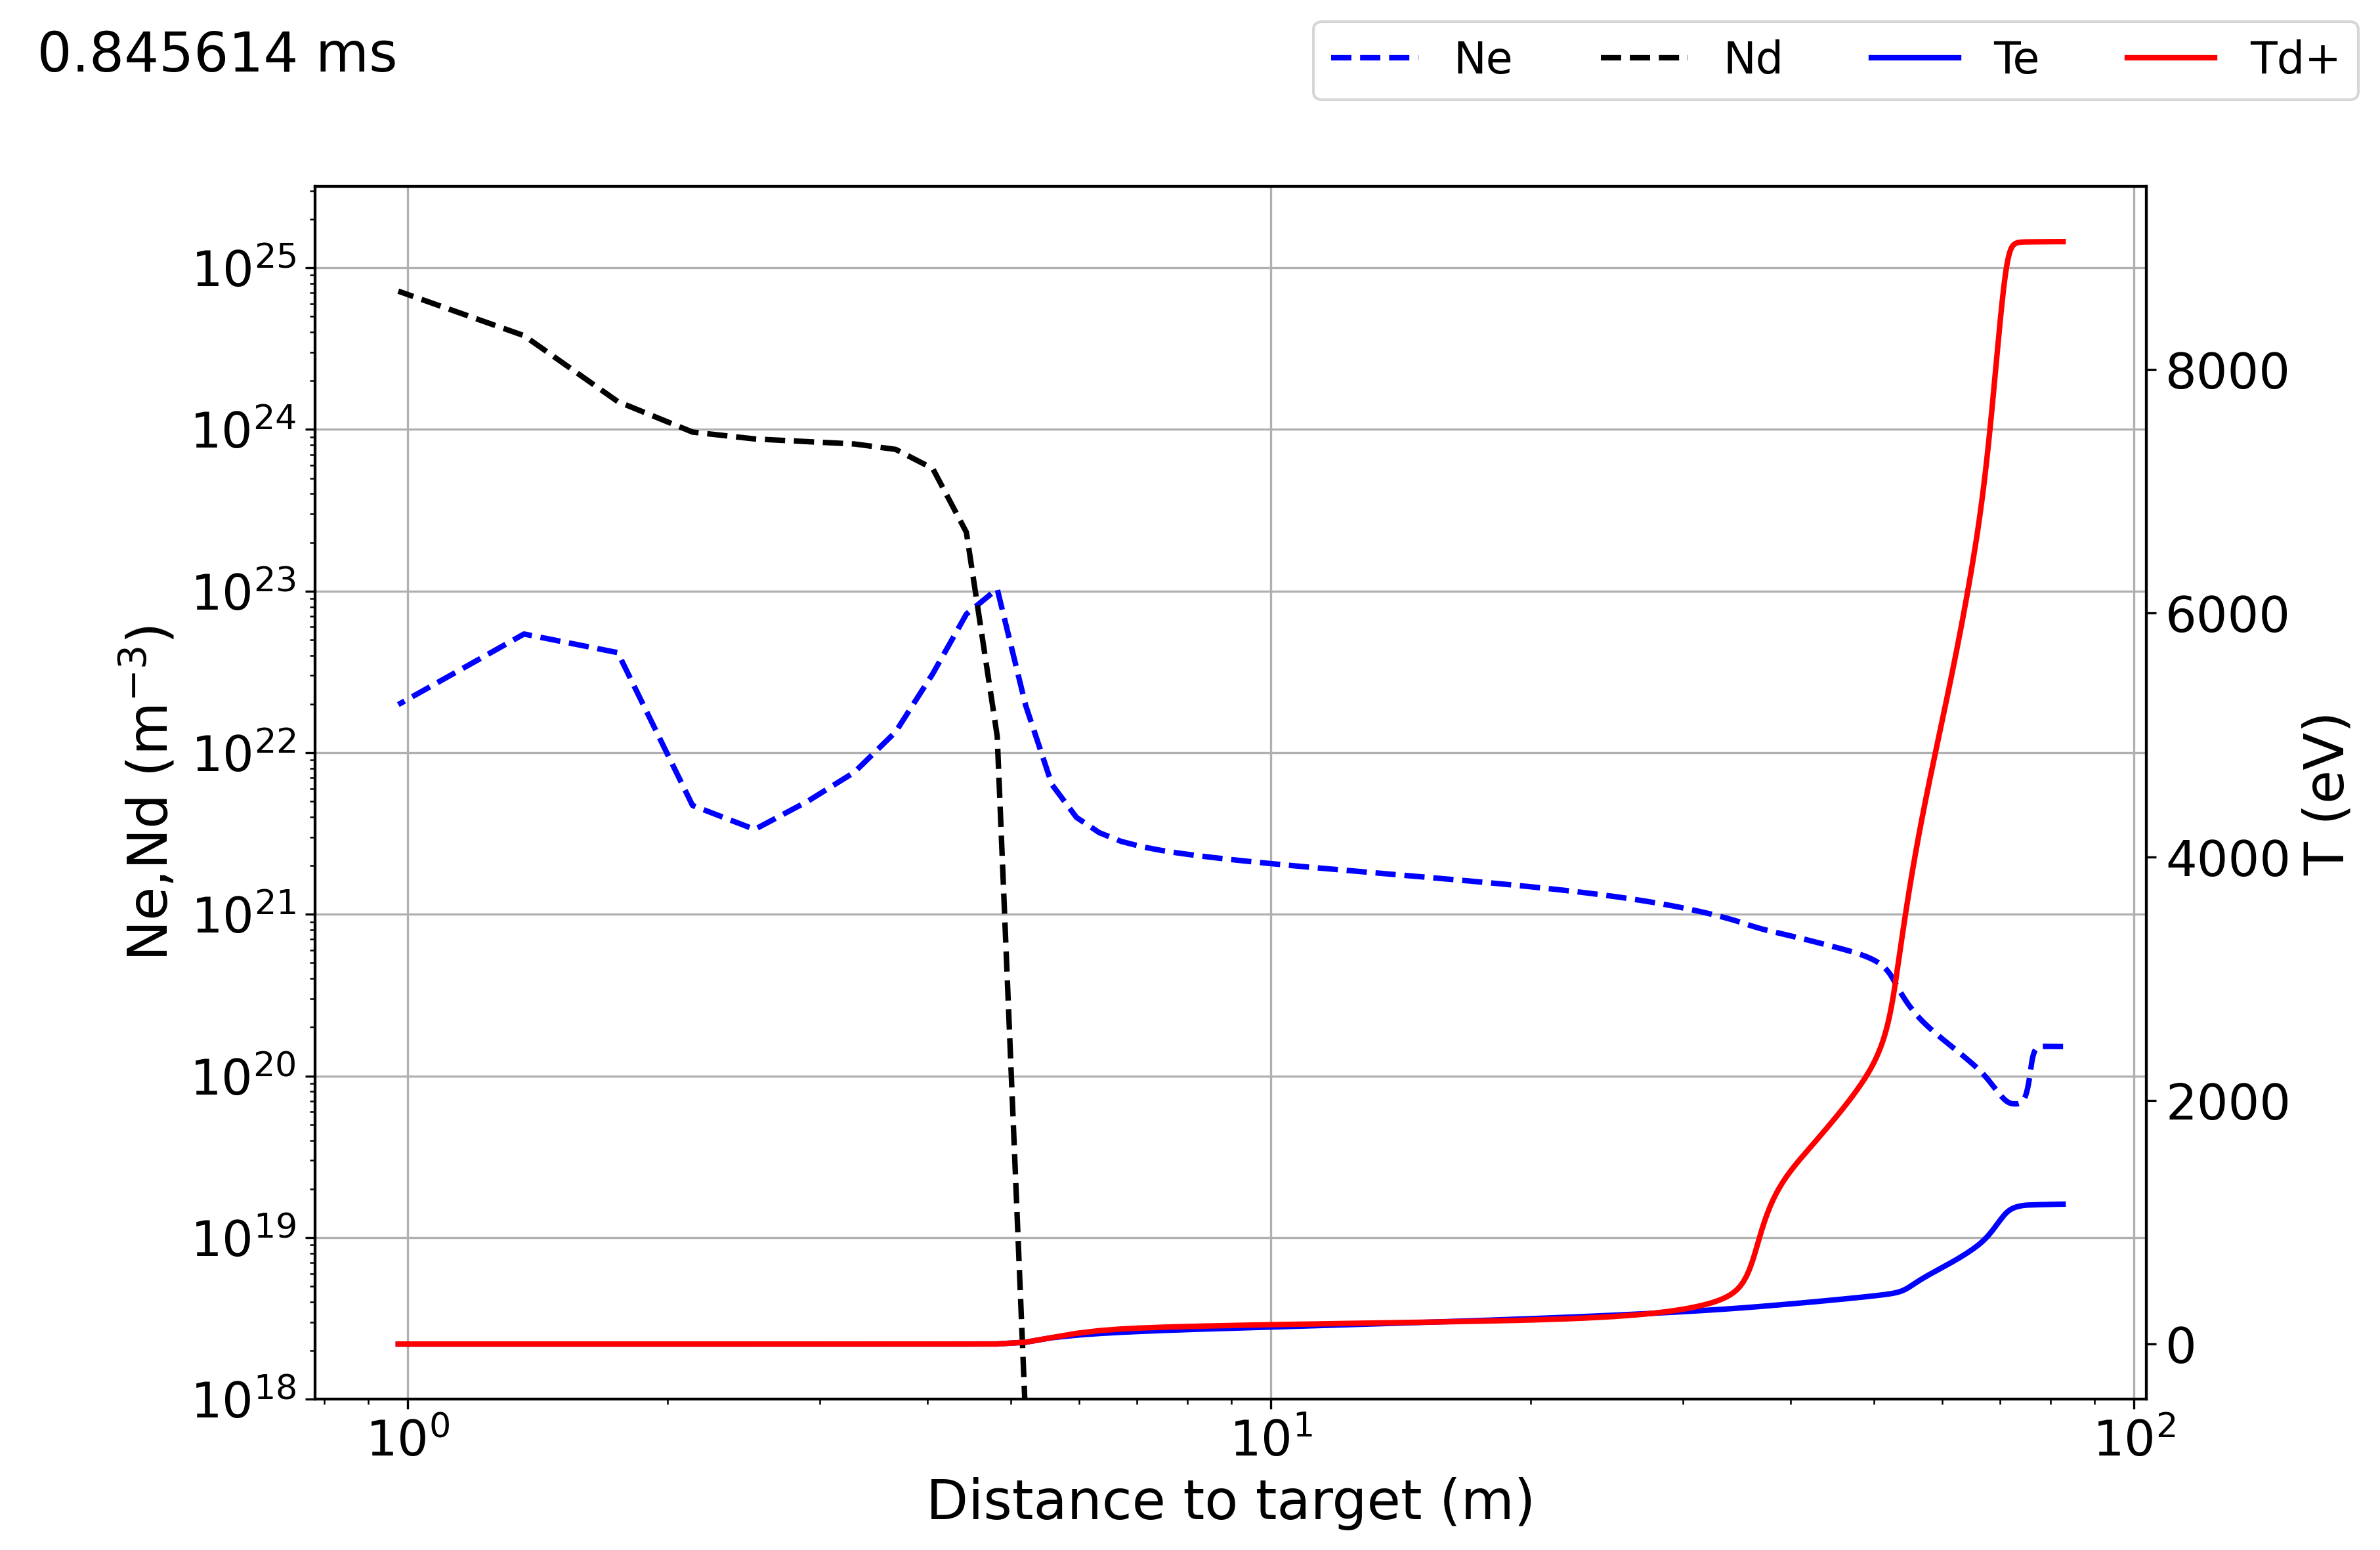

index  82


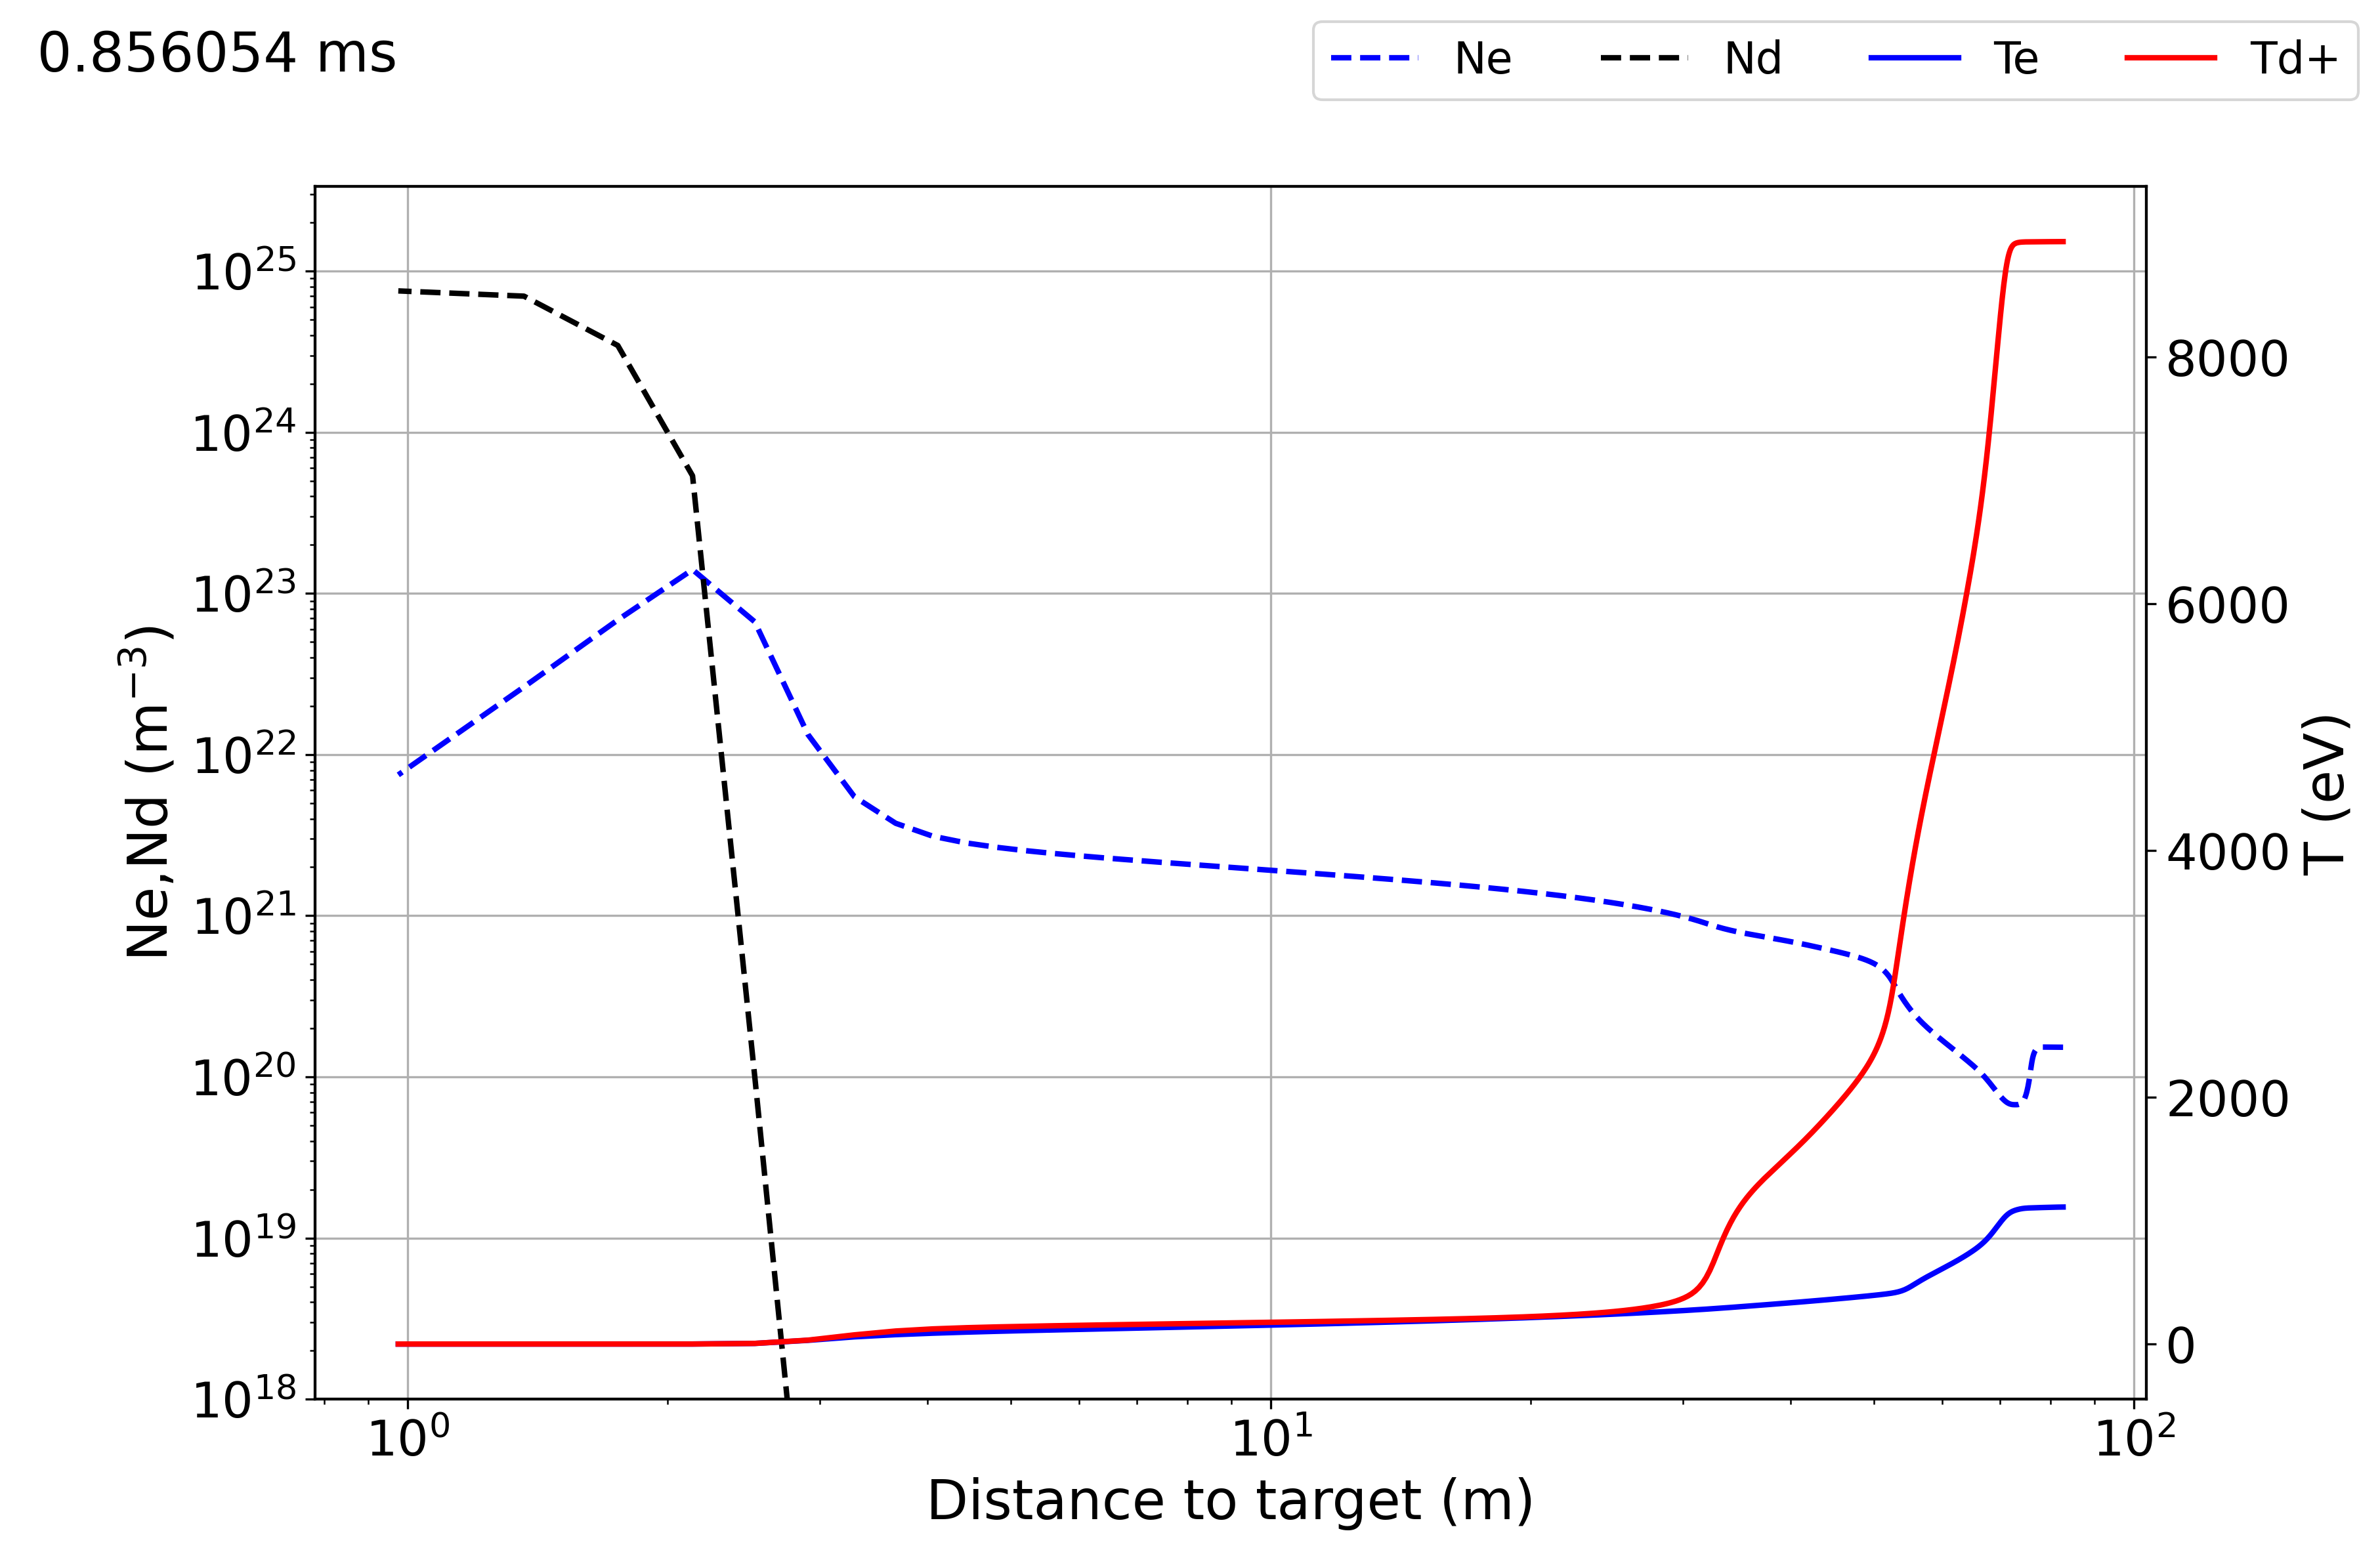

index  83


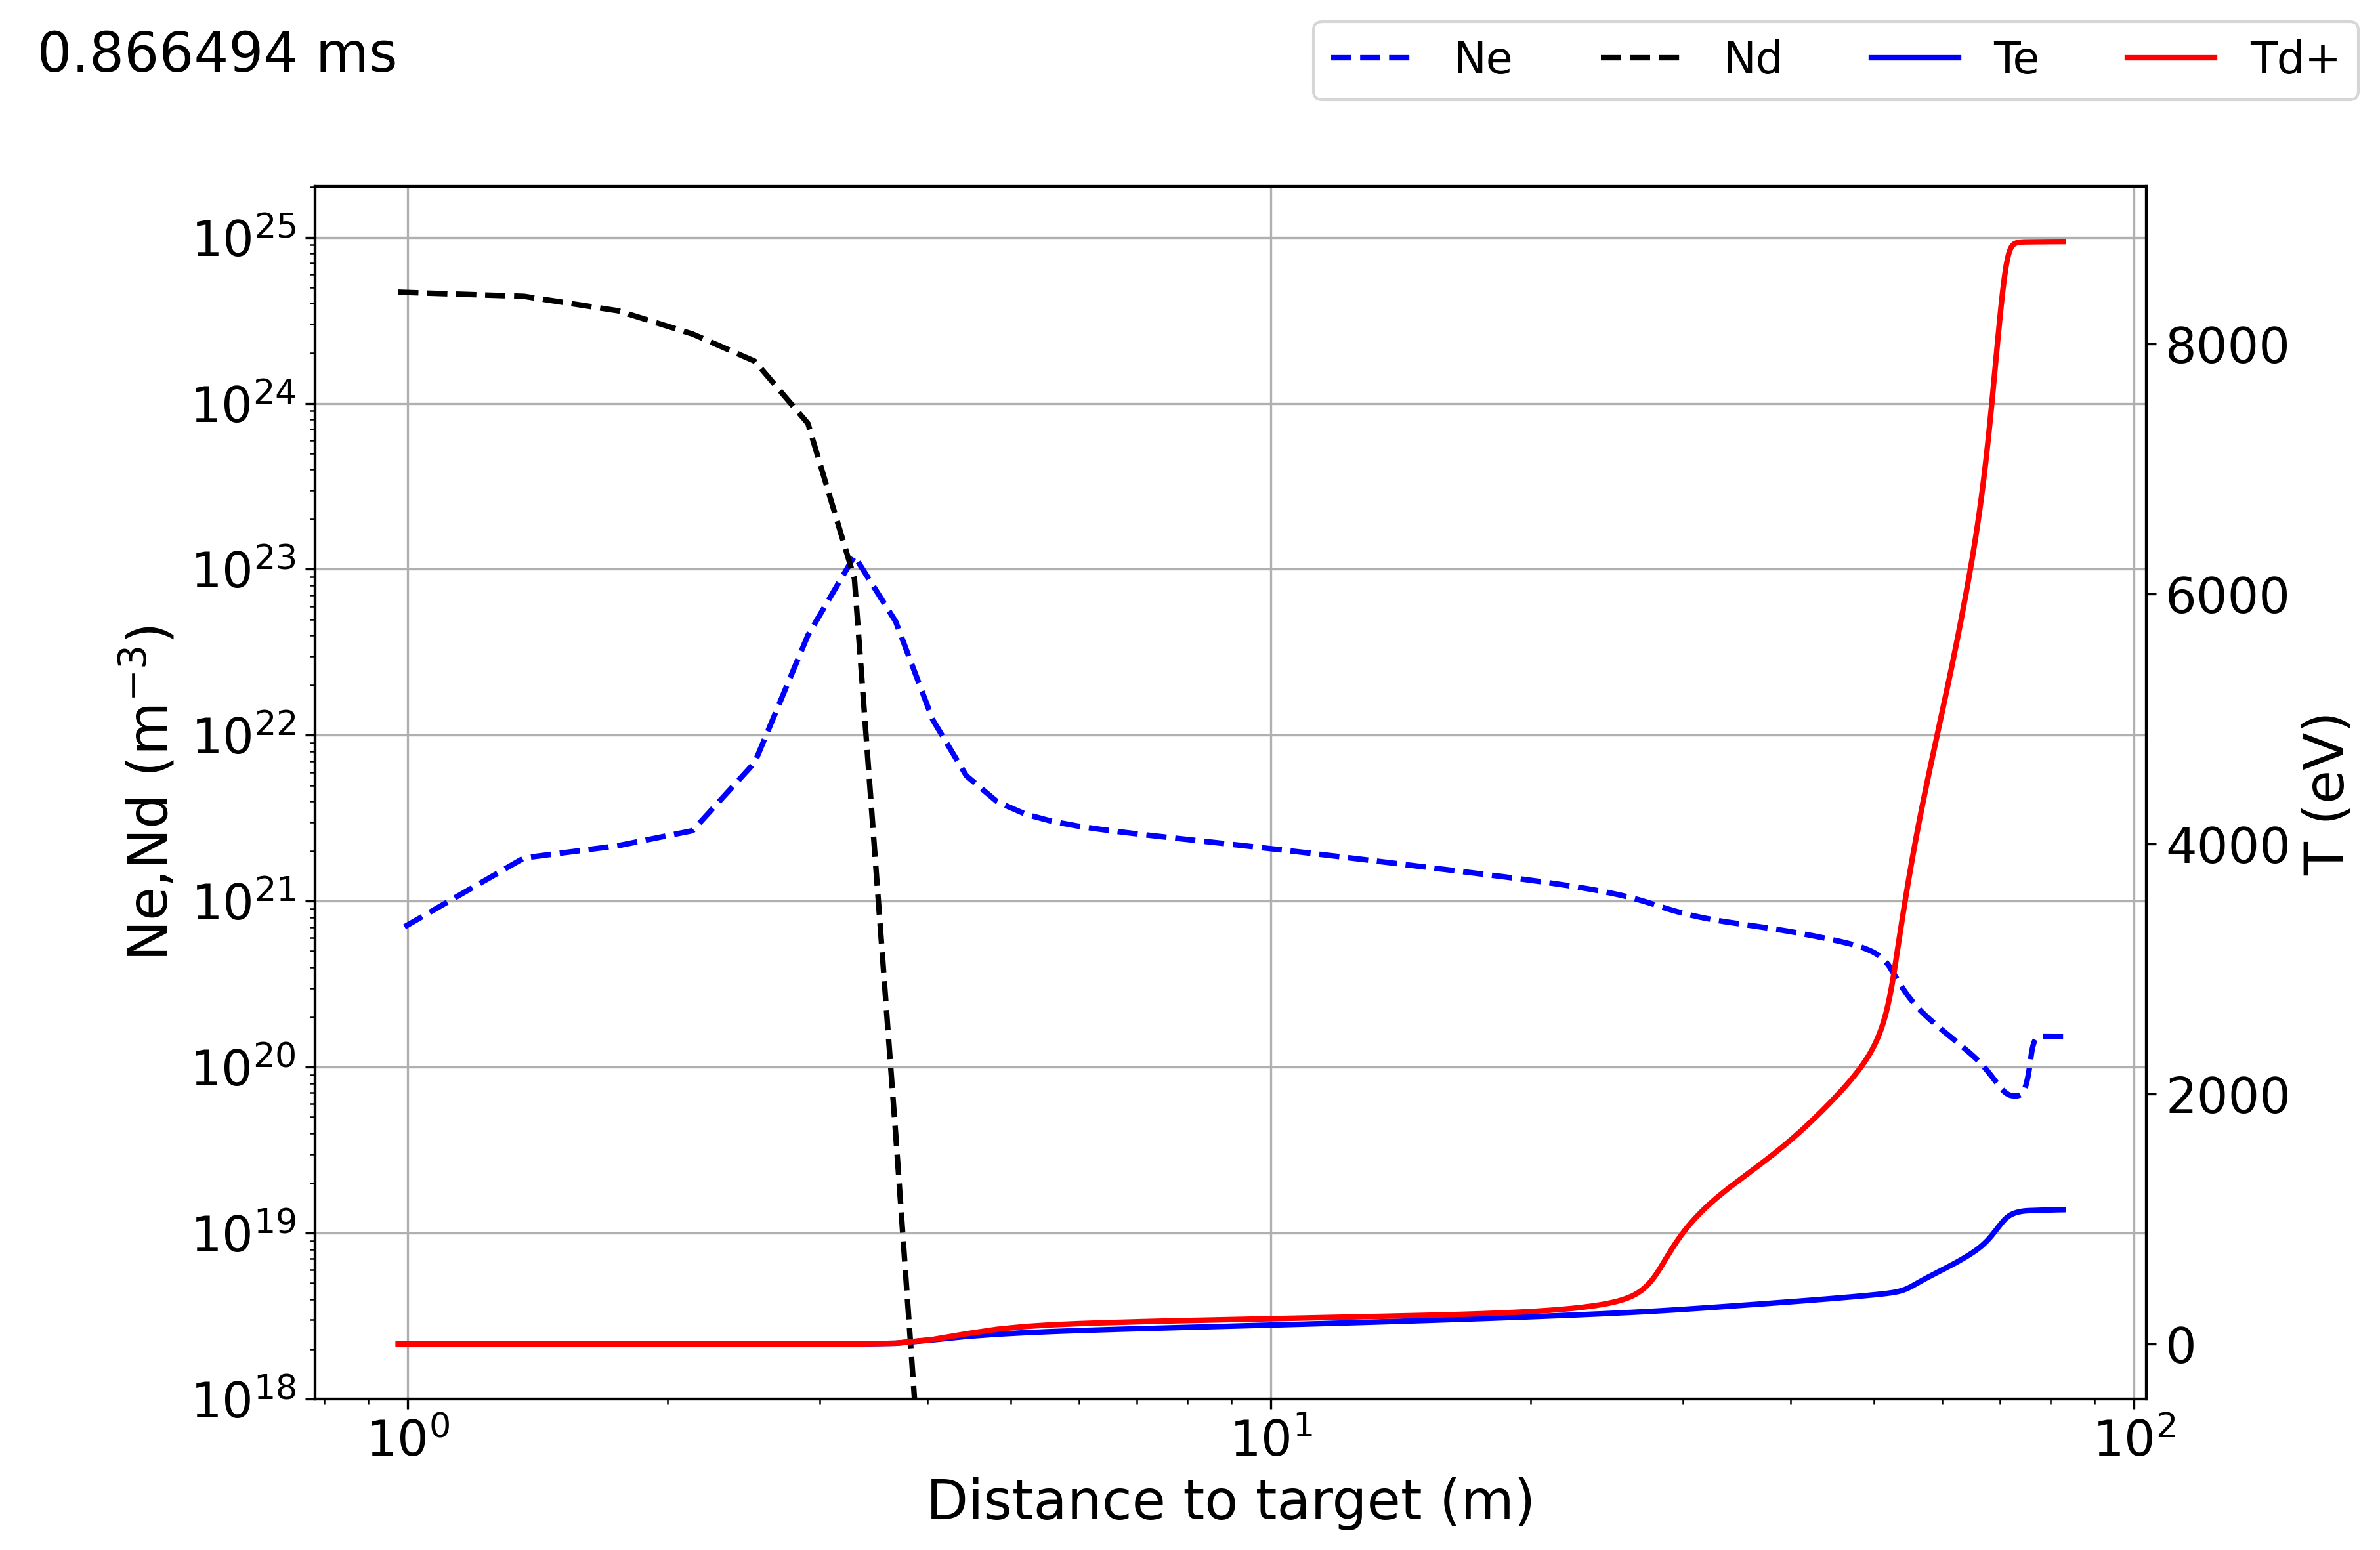

index  84


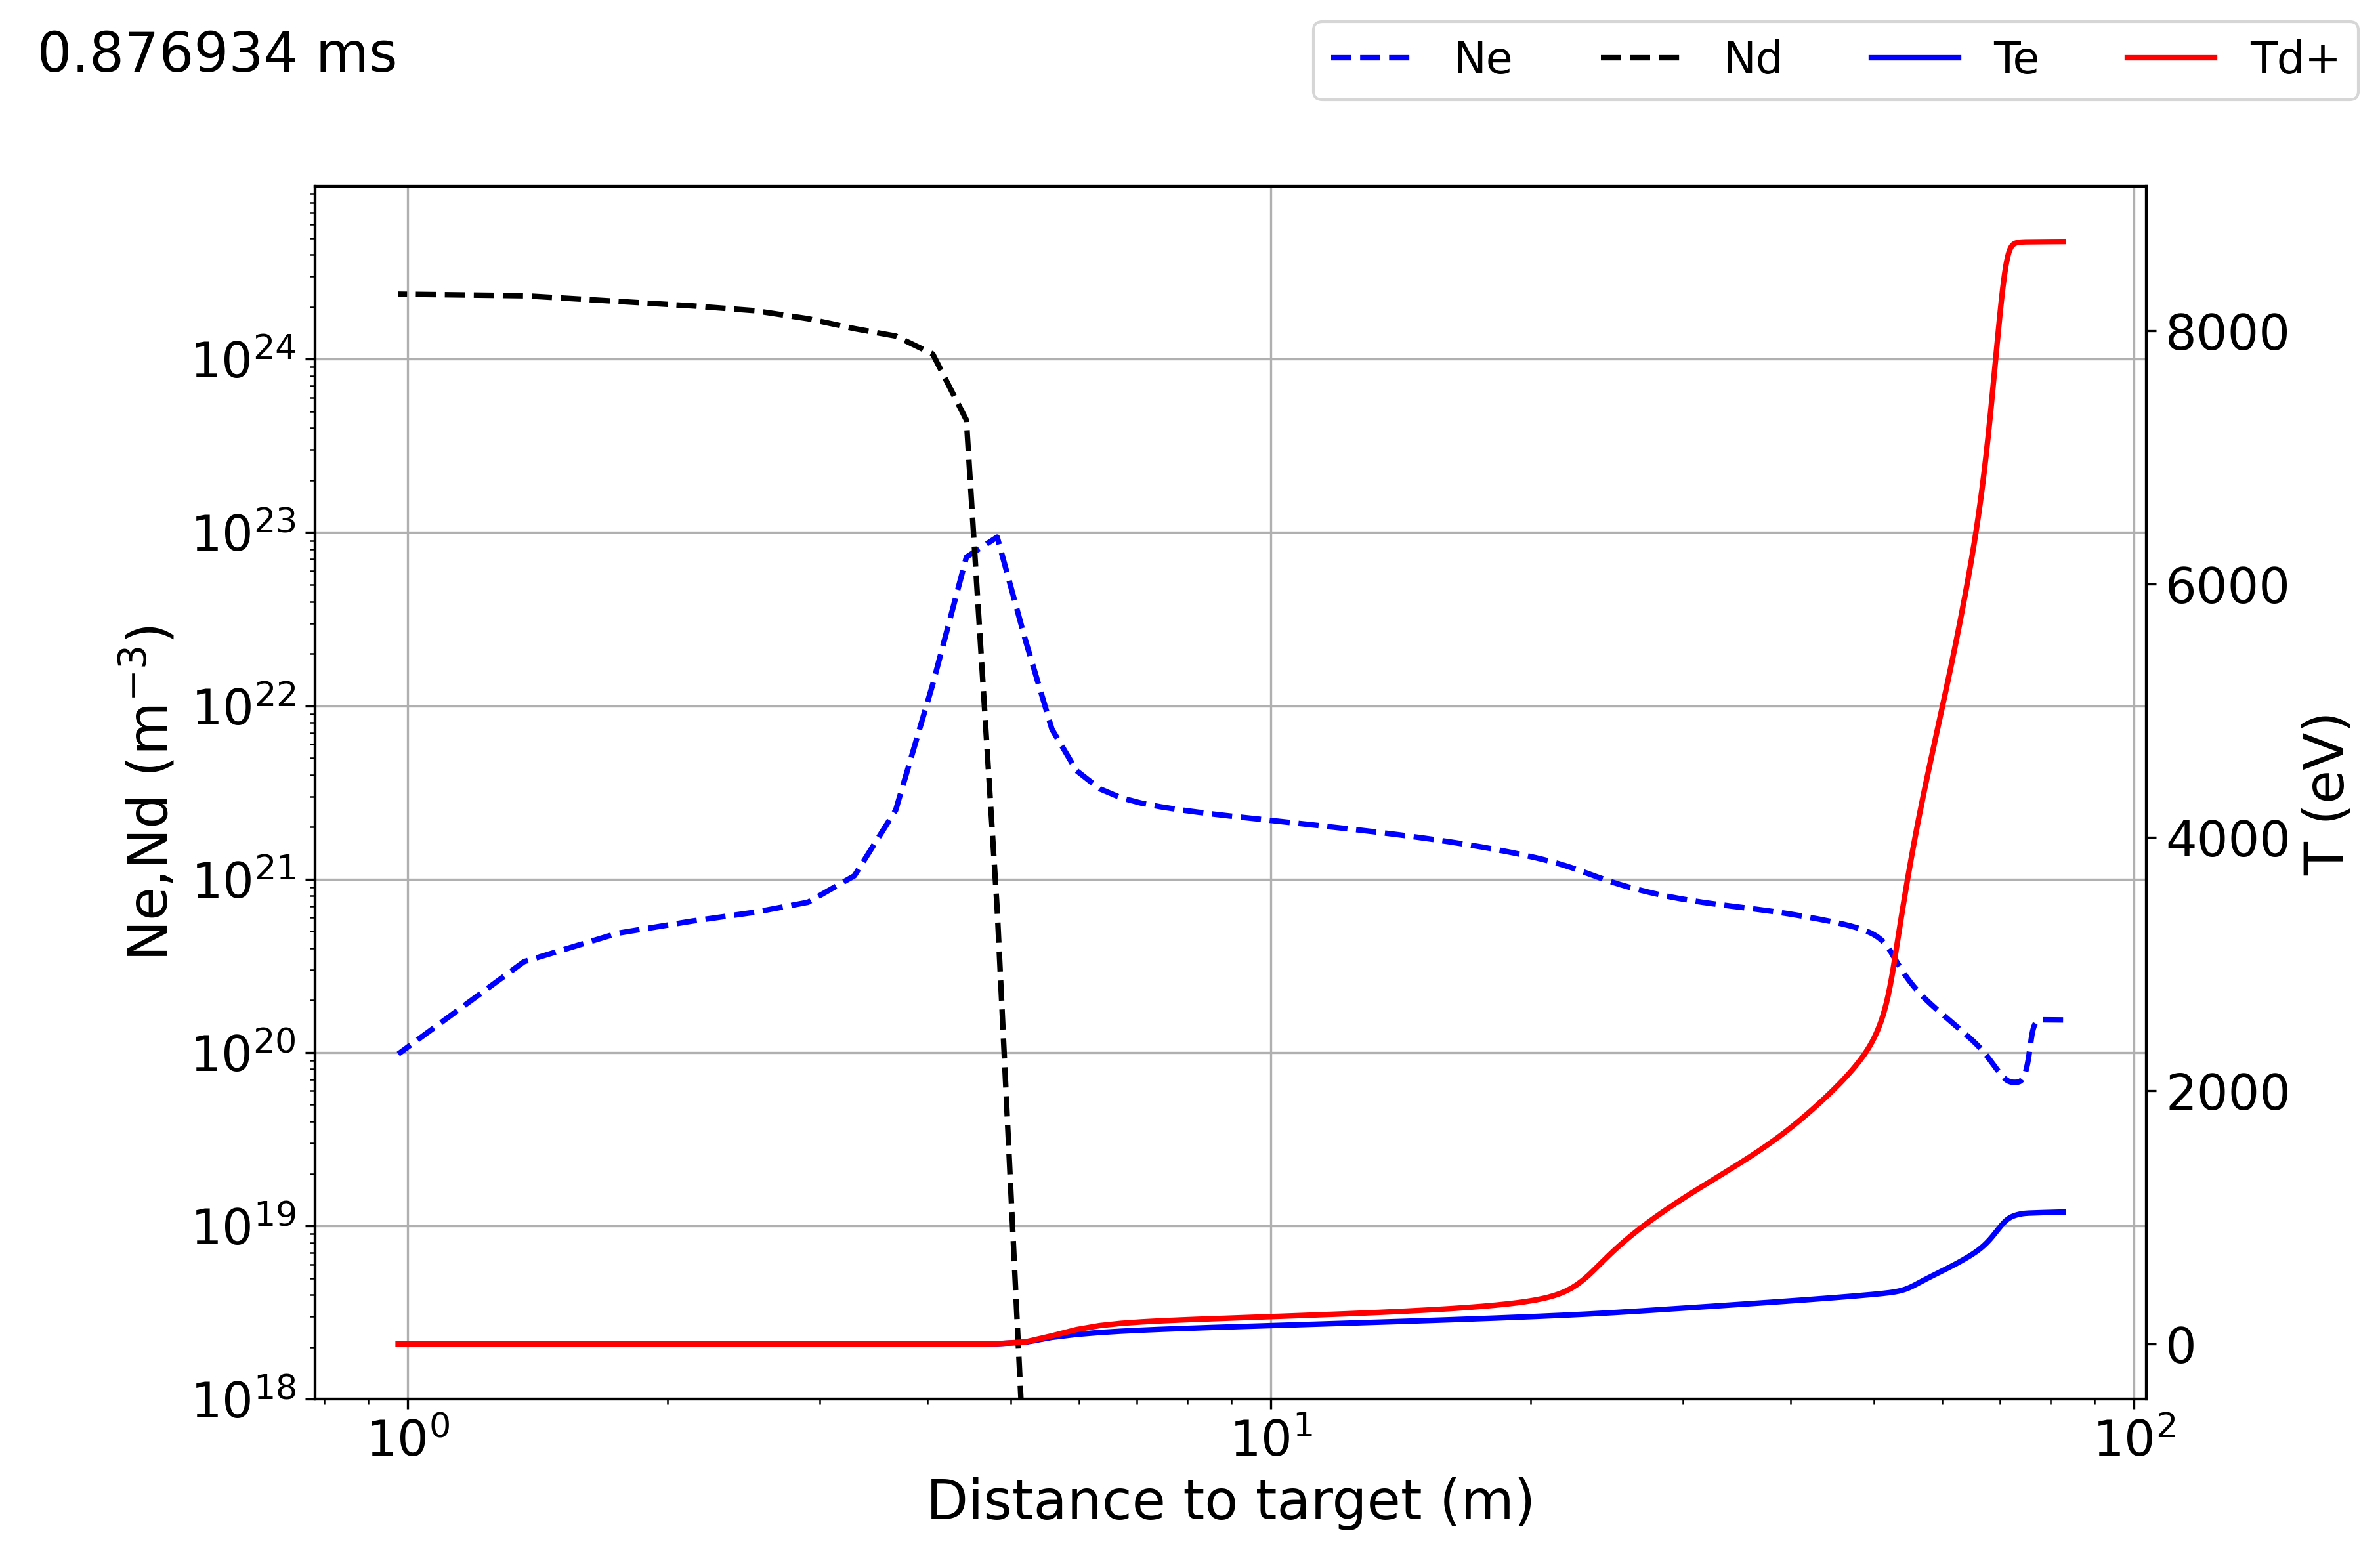

In [188]:
single_profile_plot(ds_old_1, 0)

for t in range(75, 85, 1):
    print('index ', t)
    # single_profile_plot(ds_1, t)
    single_profile_plot(ds_old_1, t)
    
    plt.show()

# Recycling

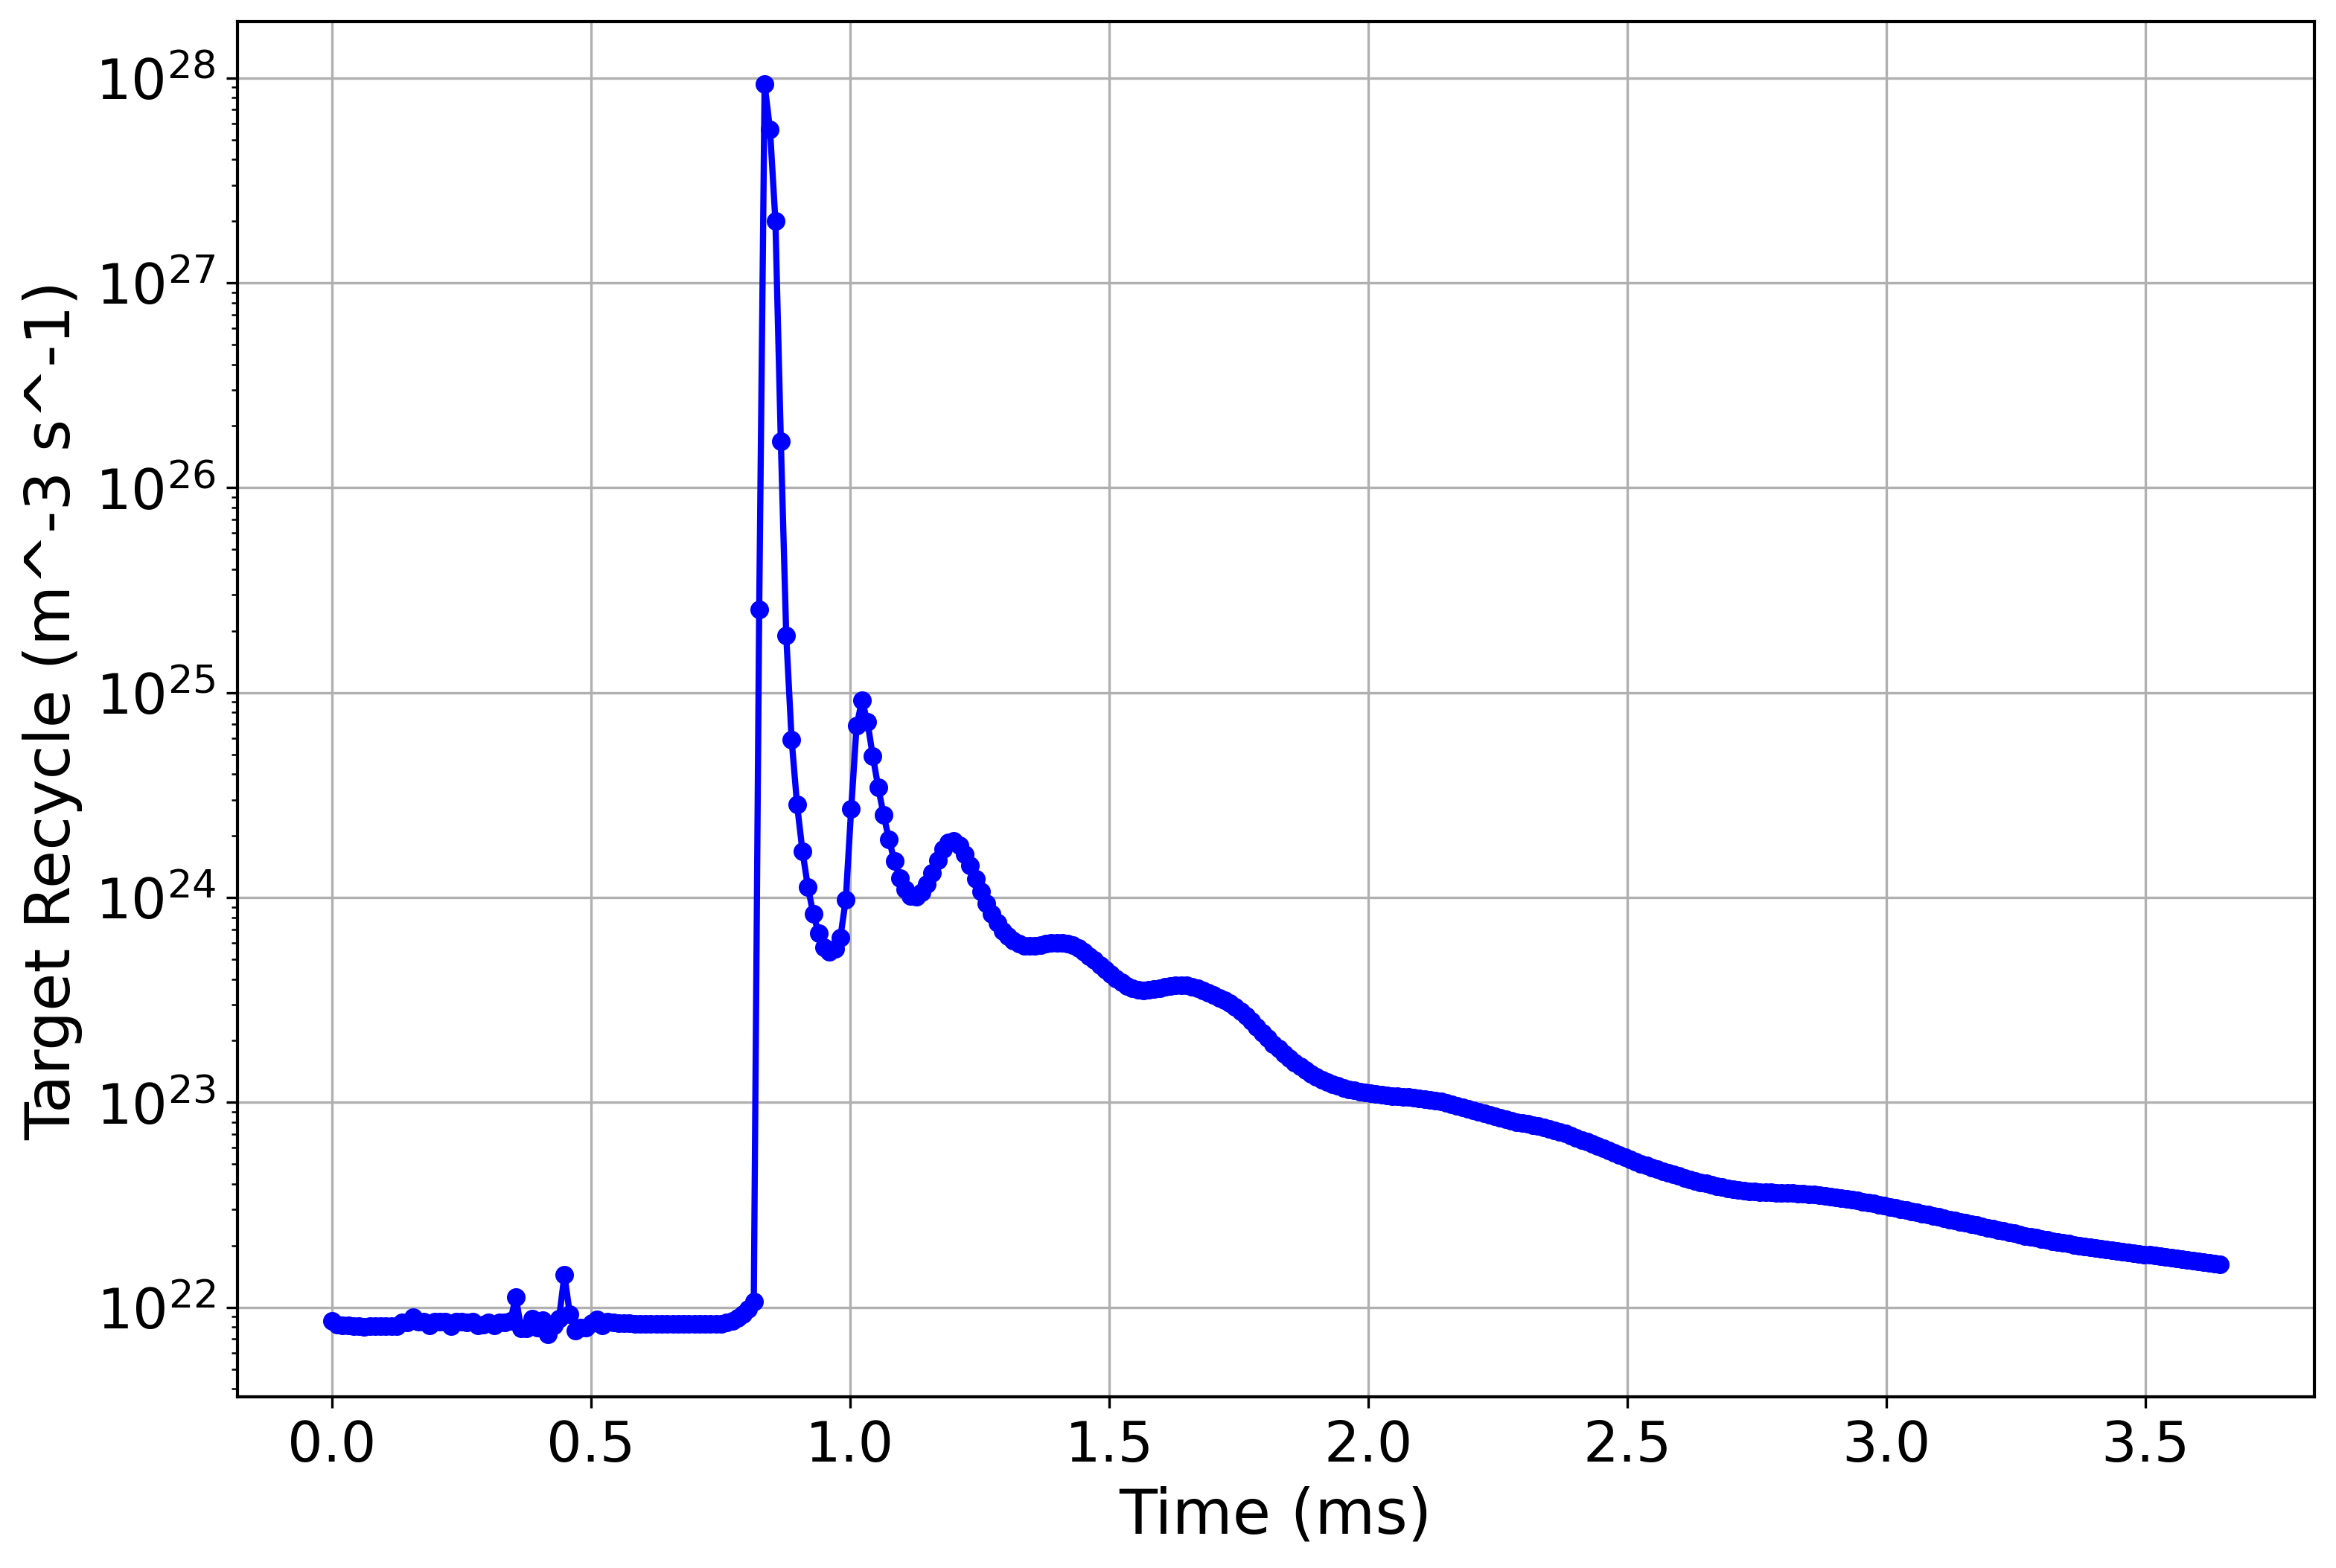

In [115]:
target_recycle = []
times = []
for t in range(0, 350, 1):

    times.append((ds_old_1['t'].values[t] - ds_old_1['t'].values[0])*1e3)
    target_recycle.append(np.max(ds_old_1['Sd_target_recycle'].values[t]))    

fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=300)
linewidth = 2
ax.plot(times, target_recycle, color='blue', label='Target Recycle', linewidth=linewidth, marker='o', markersize=5)

ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel('Target Recycle (m^-3 s^-1)', fontsize=20)
ax.set_yscale('log')

In [ ]:
print(ds_old_1['simple_pump_sink_d'].isel(t=0).units)

m^-3 / s


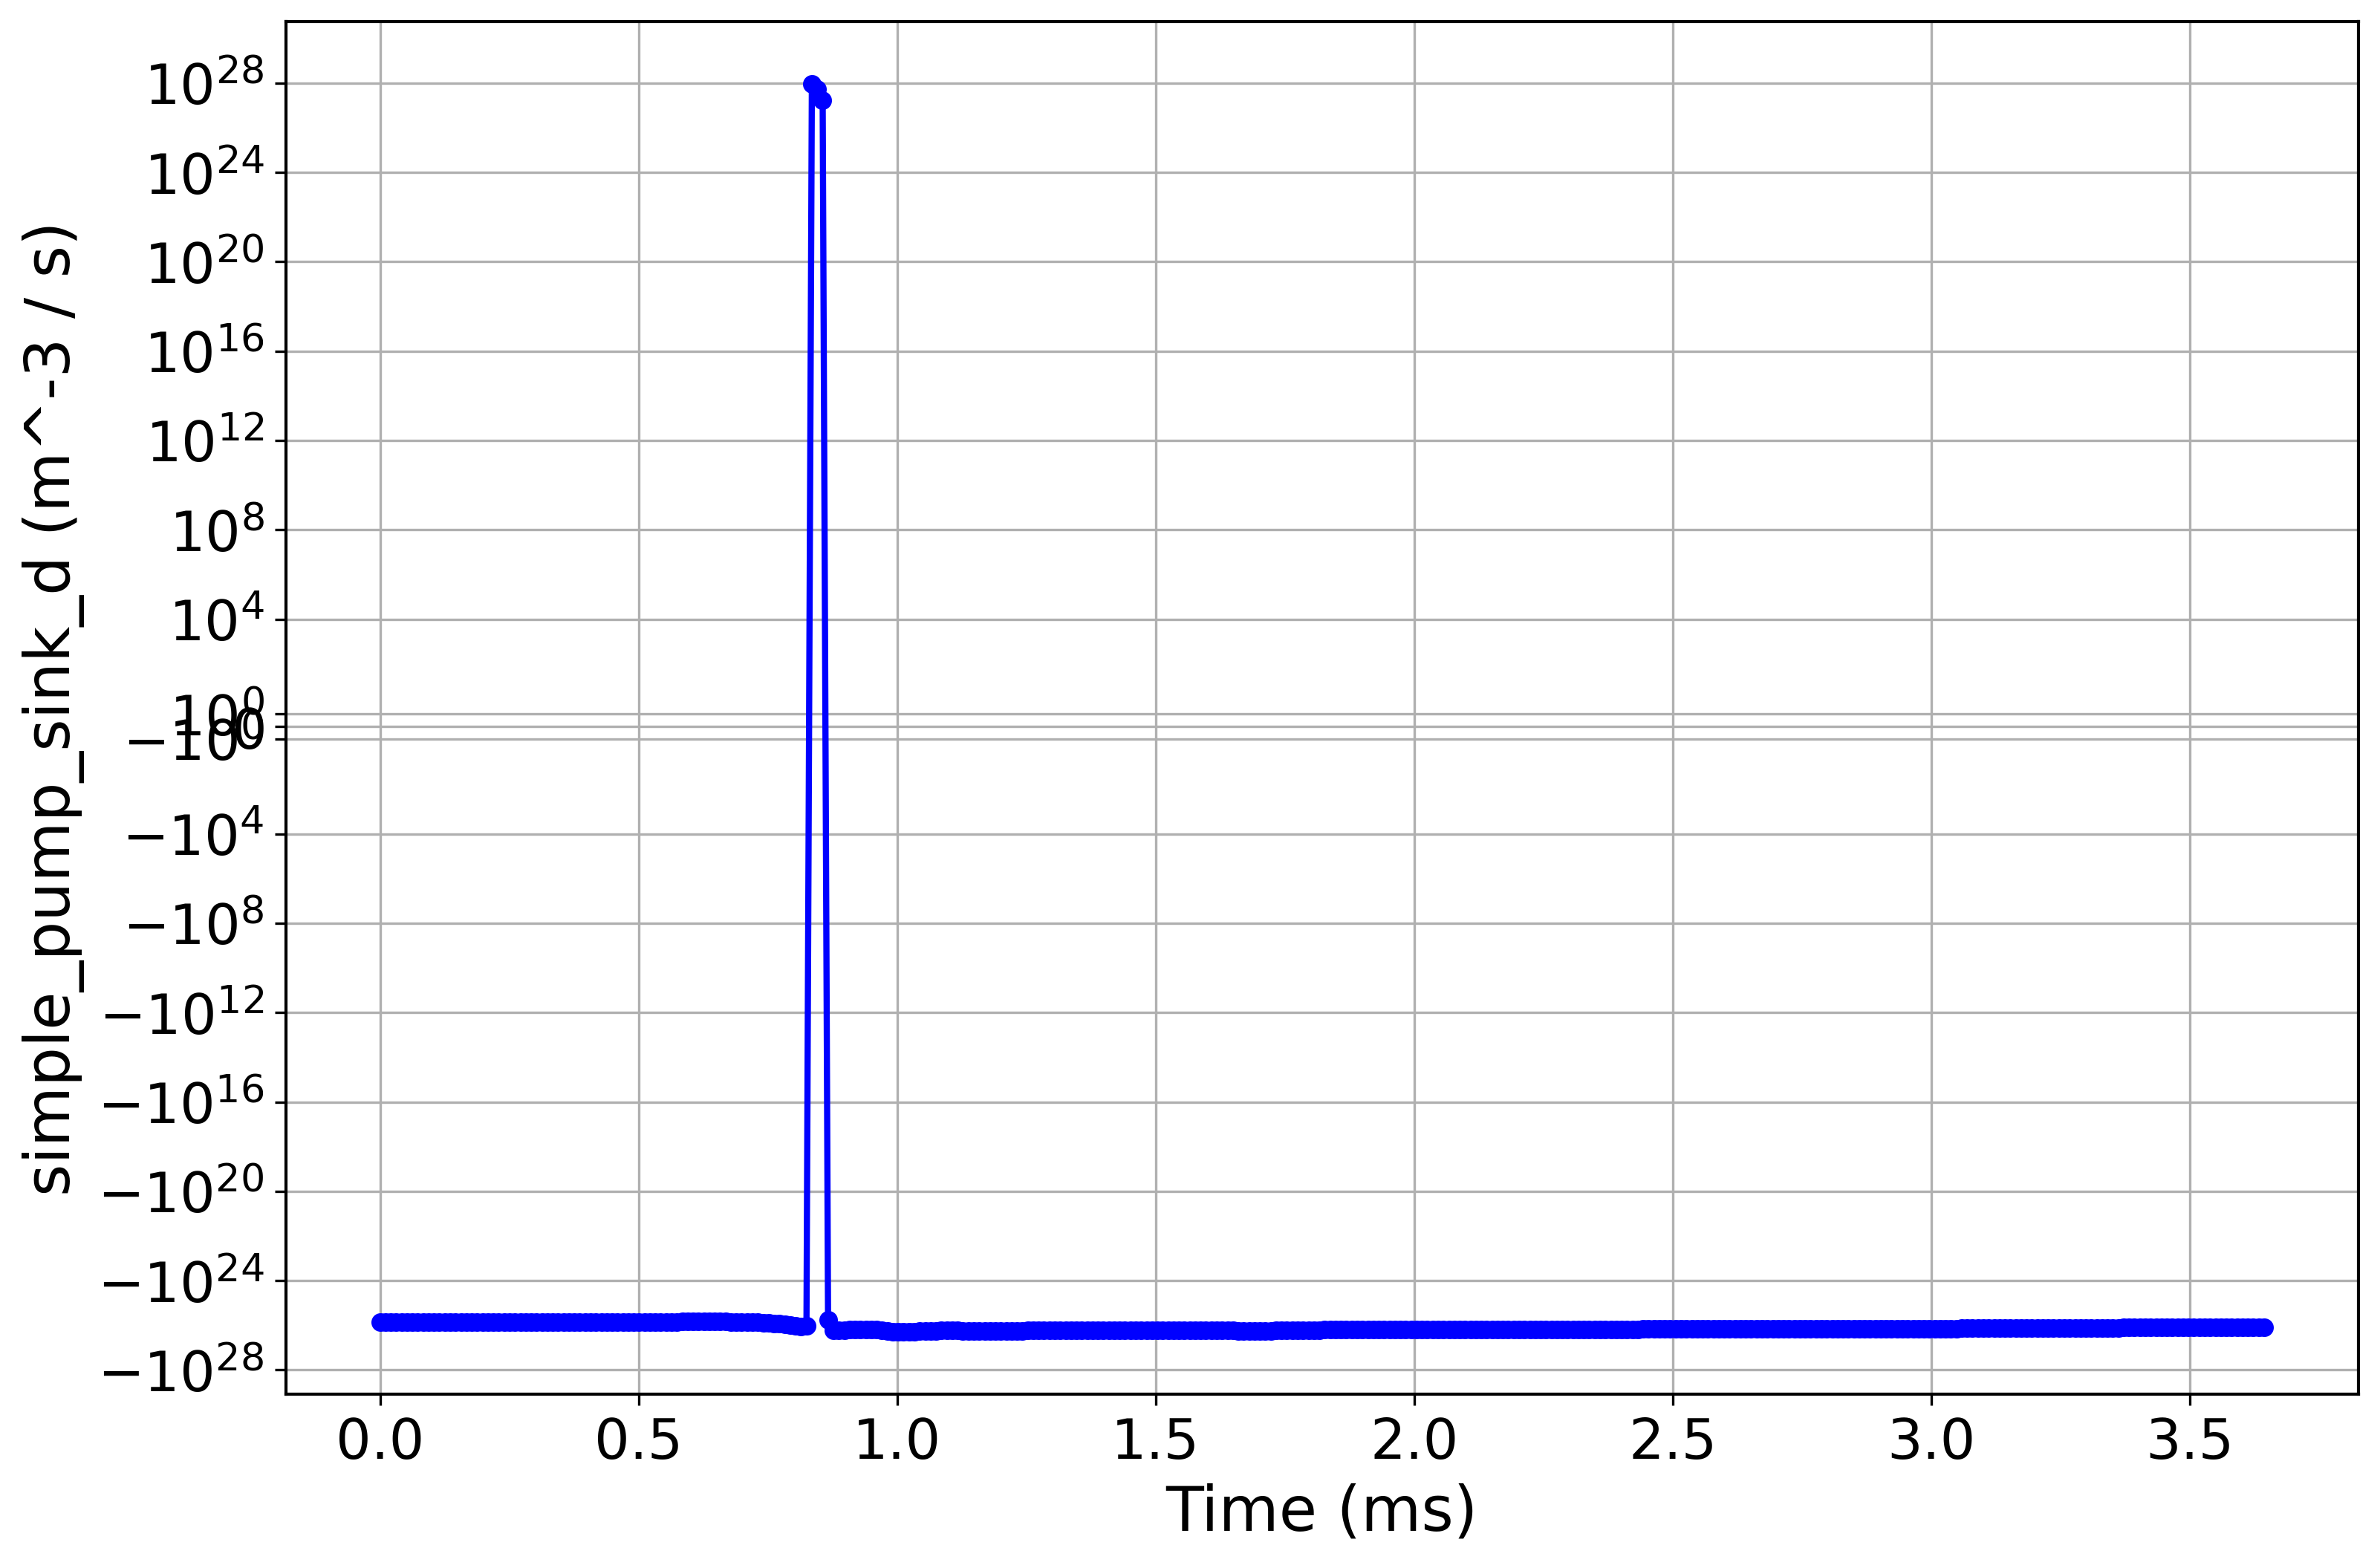

In [116]:
pump = []
times = []
for t in range(0, 350, 1):

    times.append((ds_old_1['t'].values[t] - ds_old_1['t'].values[0])*1e3)

    pump_tot = np.sum(ds_old_1['simple_pump_sink_d'].values[t][1:-1])    
    pump.append(pump_tot)    

fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=300)
linewidth = 2
ax.plot(times, pump, color='blue', label='Target Recycle', linewidth=linewidth, marker='o', markersize=5)

ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel(f'{ds_old_1["simple_pump_sink_d"].name} ({ds_old_1["simple_pump_sink_d"].units})', fontsize=20)
ax.set_yscale('symlog')

In [167]:
import numpy as np
import matplotlib.pyplot as plt

def source_sink(ds, var, time_range, symlog=True):
    """
    Plots the integrated value of a variable over time for a specified time range.

    Parameters:
    - ds: xarray.Dataset
    - var: str, variable name in the dataset
    - time_range: tuple(int, int), time index range as (start, stop)
    - symlog: bool, whether to use symlog scale on y-axis
    """

    # Initialize lists
    pump = []
    times = []

    # Select the subset using isel and a slice
    ds_subset = ds.isel(t=slice(time_range[0], time_range[1]))

    for t_idx in range(len(ds_subset['t'])):
        t_global_idx = t_idx + time_range[0]
        current_time = (ds['t'].values[t_global_idx] - ds['t'].values[0]) * 1e3  # in ms
        times.append(current_time)

        # Sum over spatial domain, removing guard cells
        pump_tot = np.sum(ds[var].isel(t=t_global_idx).values[1:-1])
        pump.append(pump_tot)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    ax.plot(times, pump, color='blue', label='Target Recycle', linewidth=2, marker='o', markersize=5)

    ax.set_xlabel('Time (ms)', fontsize=16)
    ax.set_ylabel(fr"$\sum$ {ds[var].name} ({ds[var].units})", fontsize=16)
    ax.grid(True)

    if symlog:
        ax.set_yscale('symlog')

    else:
        ax.set_yscale('log')

    # ax.legend()
    plt.tight_layout()
    plt.show()


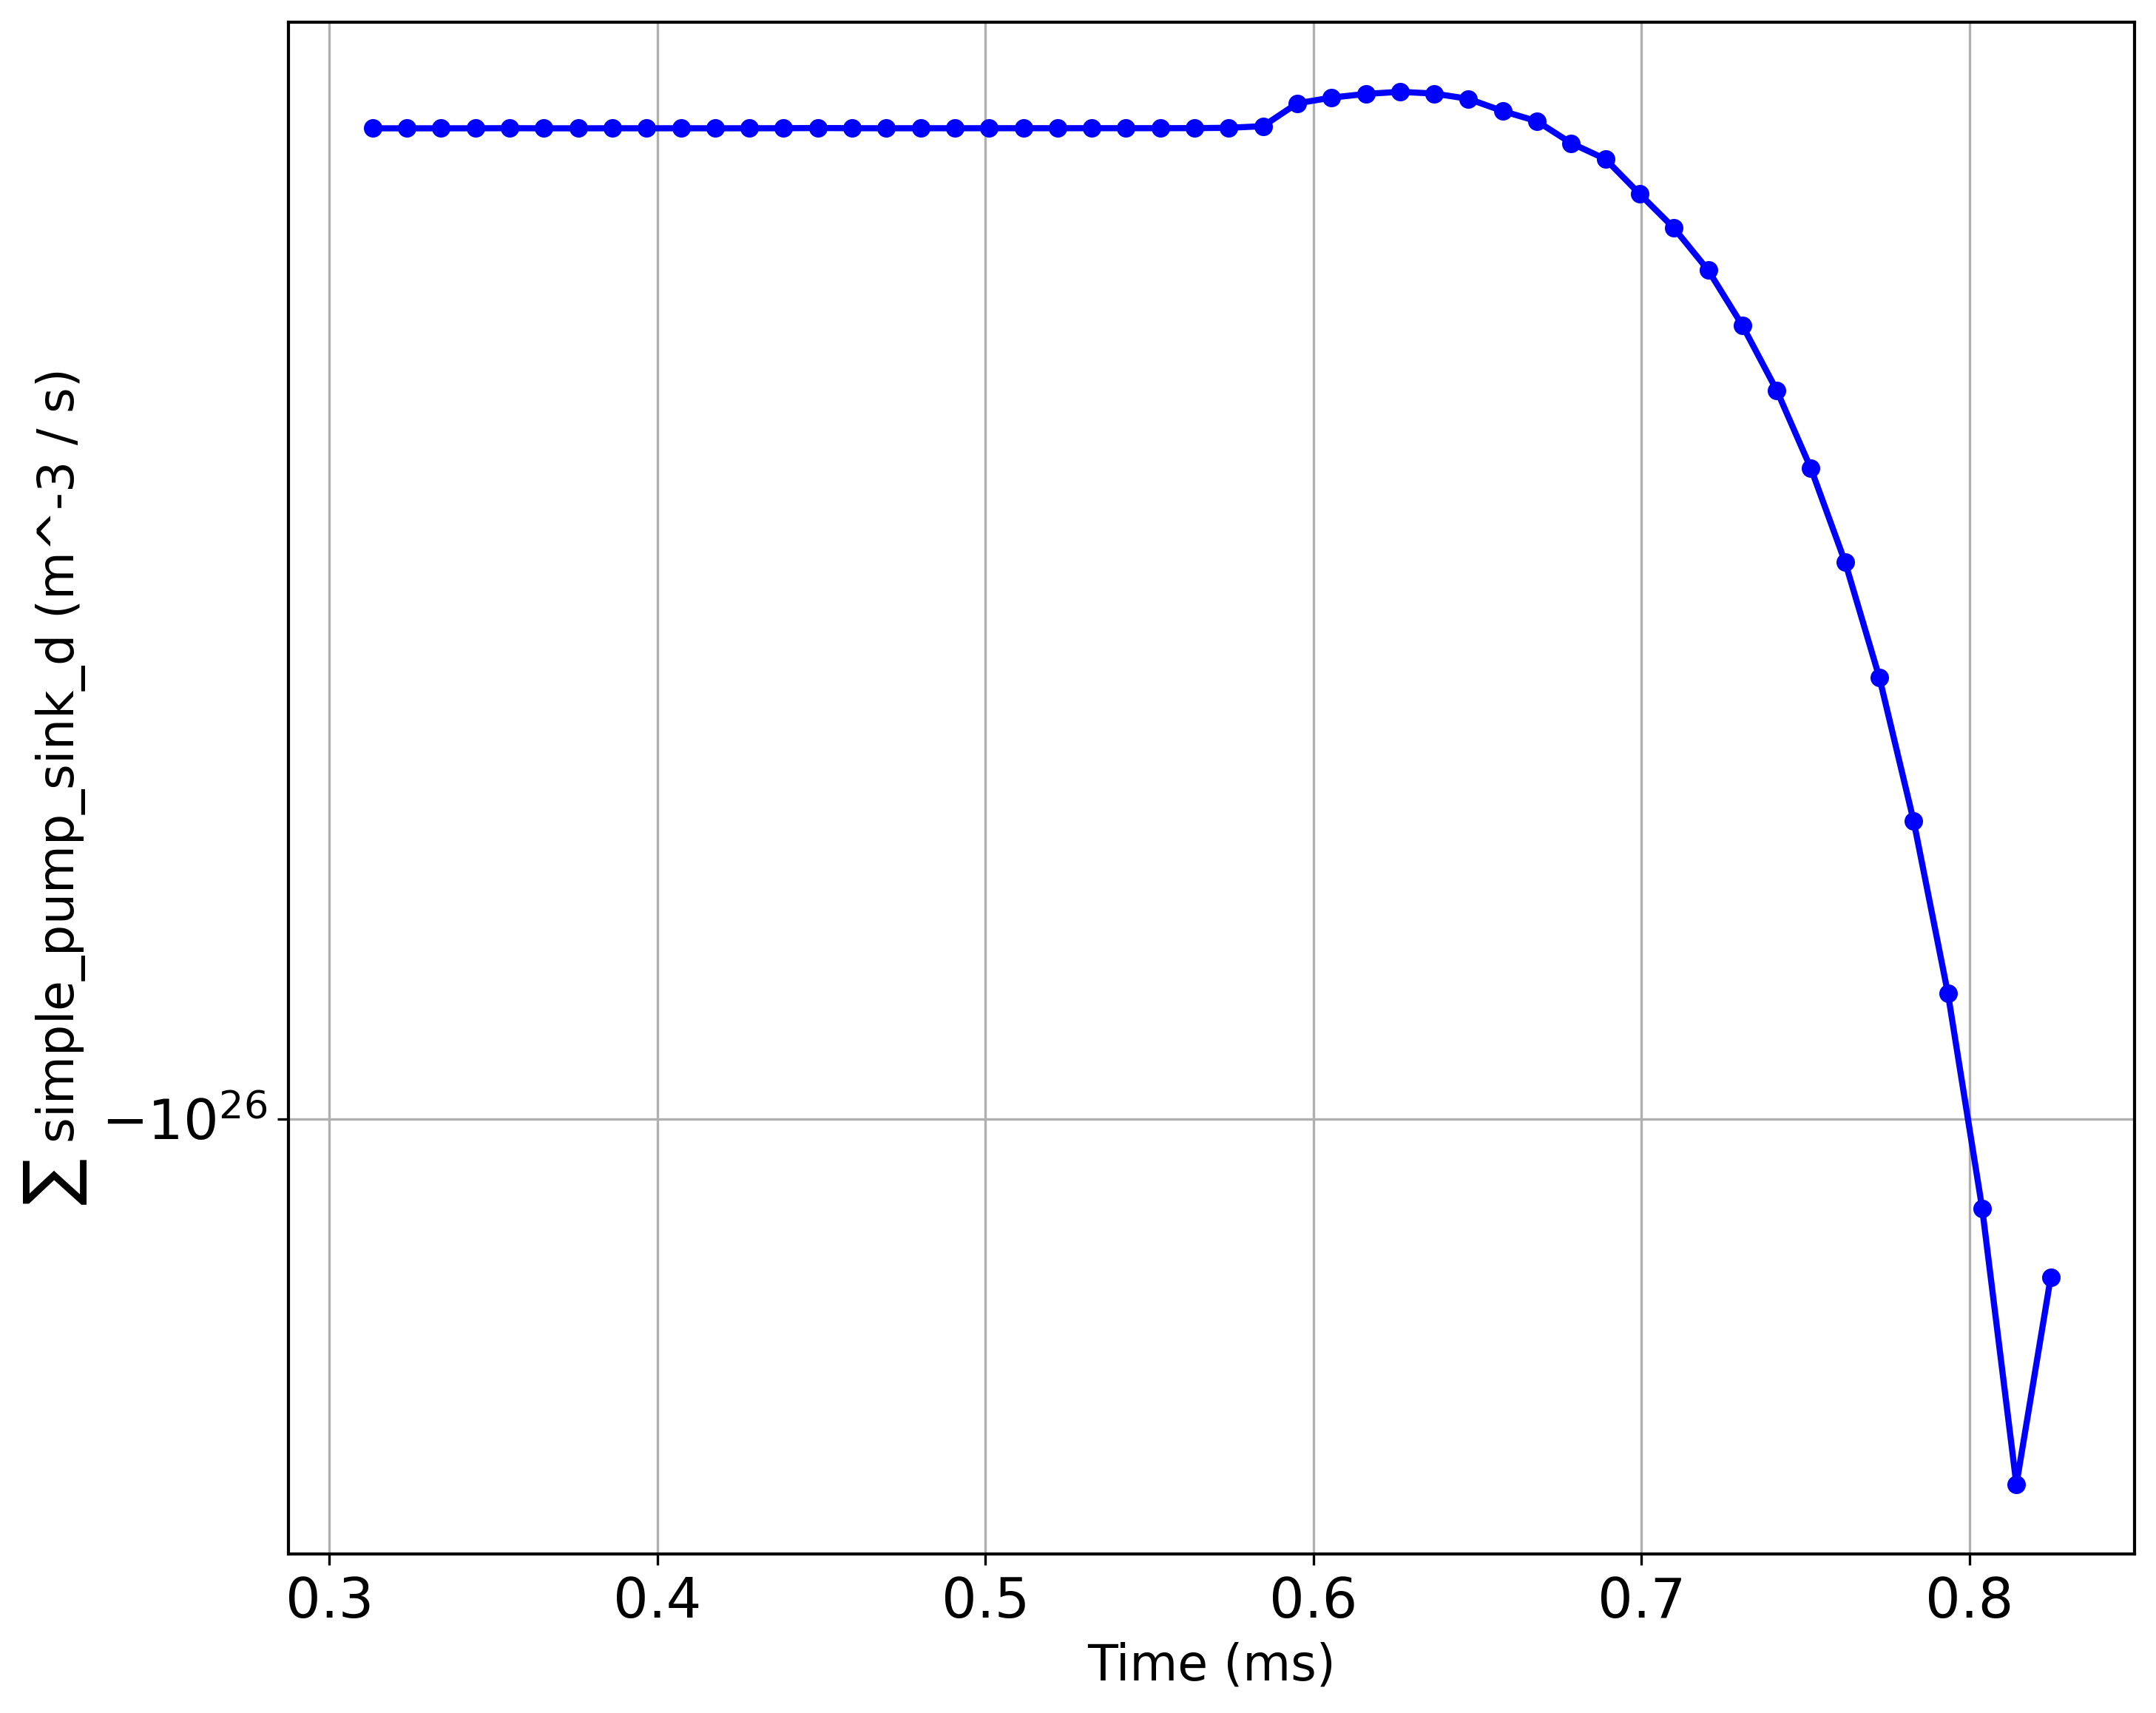

In [184]:
source_sink(ds_old_1, 'simple_pump_sink_d', (30,80), symlog = True)

# Total neutral cloud

In [135]:
neutrals = ds_old_1['Nd'].isel(t=0).values
print(np.where(neutrals > 1e19)[0][0])

cloud_indx = np.where(neutrals > 1e19)[0][0]

neutral_cloud = neutrals[cloud_indx:-2]
volume = ds_old_1['dv'].values[cloud_indx:-2]

neutral_number = np.sum(neutral_cloud * volume)



# print(f"Neutral cloud: {neutral_cloud} m^-3")
# print(f"Volume: {volume} m^3")
print(f"Neutral number: {neutral_number} #")

320
Neutral number: 2.579862250025524e+24 #


## Burnthrough

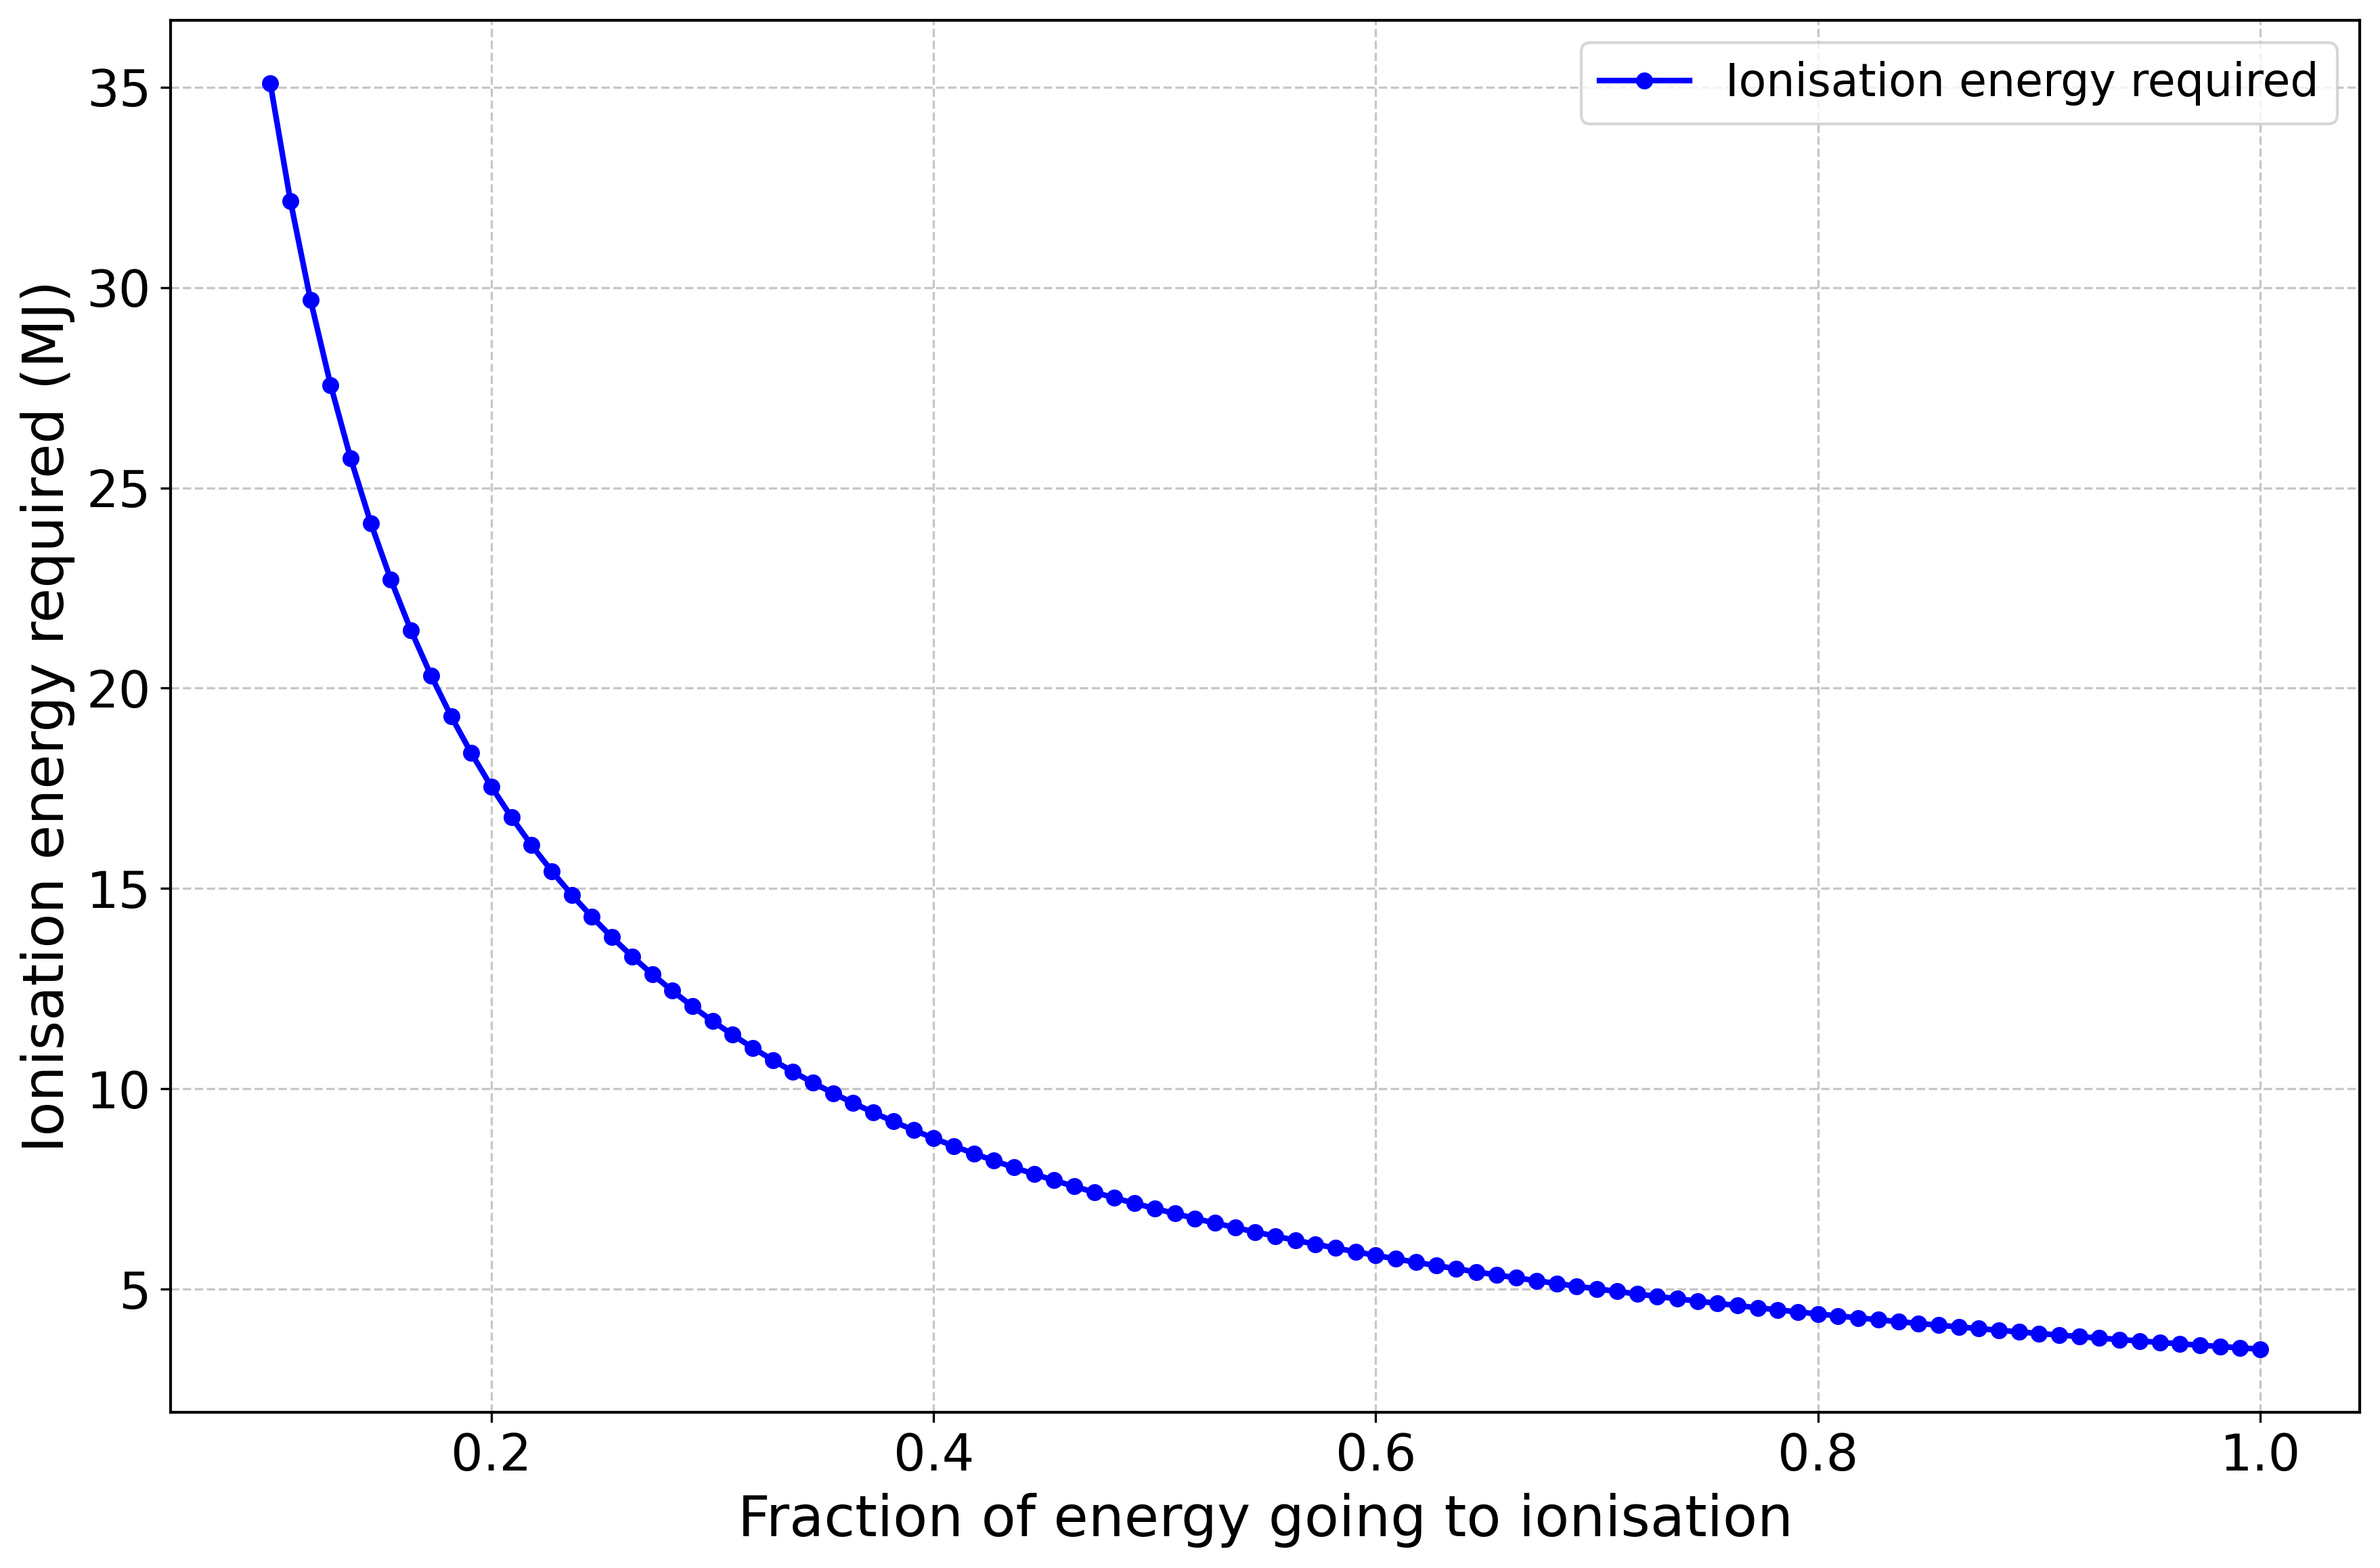

In [160]:
import matplotlib.pyplot as plt

# Constants
E_ion = 13.6  # eV
# Fractions of energy going to ionisation
f_ion = np.linspace(0.1, 1, 100)  # 1% to 100%

# Calculate energy required for each fraction
energy_required = [
    neutral_number * E_ion * 1e-19 / f  # Convert to Joules
    for f in f_ion
]

# Convert to MJ for easier reading
energy_required_MJ = [e * 1e-6 for e in energy_required]

elm_energy = [15.5, 31, 46.5]

# Plot as a line
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
ax.plot(f_ion, energy_required_MJ, color='blue', linewidth=2, marker='o', markersize=5, label='Ionisation energy required')

ax.set_xlabel('Fraction of energy going to ionisation', fontsize=20)
ax.set_ylabel('Ionisation energy required (MJ)', fontsize=20)
# ax.axhline(elm_energy[0], color='gold', linestyle='--', label='15.5 MJ ELM')
# ax.axhline(elm_energy[1], color='red', linestyle='--', label='31 MJ ELM')
# ax.axhline(elm_energy[2], color='brown', linestyle='--', label='46.5 ELM')

# ax.set_title('Ionisation Energy vs. Energy Fraction', fontsize=22)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()


# Reattach???

In [3]:
works = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-04_updated_glimmer/scenario_development/Detached/case_09_cold_start_detached_07_x2_power', guard_replace = False, use_squash=True).ds

- Looking for squash file
- Squashoutput file not found, creating...
- Done
Skipping unnormalisation


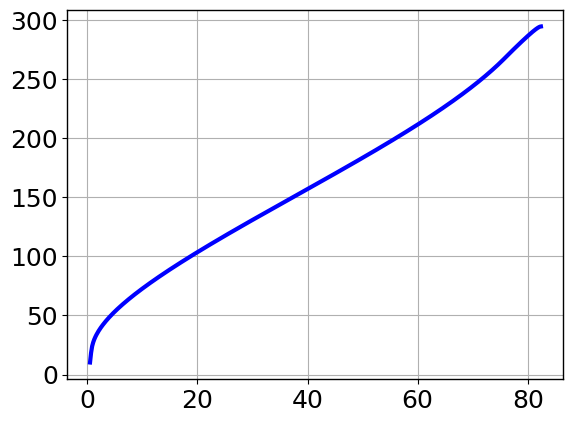

In [4]:
ds = works.copy().isel(t=-1)
plt.plot(ds['y'][::-1][2:-2], ds['Te'][2:-2], color='blue', label='Te', linewidth=linewidth)